### Experiment 8: Clustering Human Activity Recognition Data using K-Means, DBSCAN and Hierarchical Clustering
#### Isha Venkataraman - 3122247001023 (MTech Integrated CSE)

Aim: To apply K-Means, DBSCAN and Hierarchical Agglomerative Clustering on the UCI Human Activity Recognition (HAR) smartphone dataset, choose the number of clusters using the elbow and silhouette methods, tune DBSCAN's eps and min_samples, compare linkage criteria for hierarchical clustering, and evaluate all three algorithms using internal (Silhouette, Davies-Bouldin, Calinski-Harabasz) and external (ARI, NMI) metrics against the true activity labels

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score, confusion_matrix)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.optimize import linear_sum_assignment

IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
RNG = 42
np.random.seed(RNG)
print("Libraries imported successfully.")

Libraries imported successfully.


##### Loading the dataset
Reading the UCI HAR Dataset (561 pre-computed time and frequency domain features per 2.56 s window). The provided train and test partitions are merged because clustering is unsupervised and does not need a held-out split.

In [2]:
DATA_DIR = "UCI HAR Dataset"

features = pd.read_csv(os.path.join(DATA_DIR, "features.txt"), sep=r"\s+", header=None, names=["idx", "name"])["name"].tolist()
# a few feature names repeat in the original file, so make them unique
seen = {}
feature_names = []
for f in features:
    if f in seen:
        seen[f] += 1
        feature_names.append(f"{f}_{seen[f]}")
    else:
        seen[f] = 0
        feature_names.append(f)

activity_map = pd.read_csv(os.path.join(DATA_DIR, "activity_labels.txt"), sep=r"\s+", header=None, index_col=0)[1].to_dict()

def load_split(split):
    X = np.loadtxt(os.path.join(DATA_DIR, split, f"X_{split}.txt"))
    y = np.loadtxt(os.path.join(DATA_DIR, split, f"y_{split}.txt")).astype(int)
    s = np.loadtxt(os.path.join(DATA_DIR, split, f"subject_{split}.txt")).astype(int)
    return X, y, s

X_tr, y_tr, s_tr = load_split("train")
X_te, y_te, s_te = load_split("test")
X = np.vstack([X_tr, X_te])
y = np.concatenate([y_tr, y_te])
subjects = np.concatenate([s_tr, s_te])

df = pd.DataFrame(X, columns=feature_names)
df["activity"] = [activity_map[v] for v in y]
df["subject"] = subjects

print(f"Train windows: {X_tr.shape[0]}, Test windows: {X_te.shape[0]}, Combined: {X.shape[0]}")
print(f"Features: {X.shape[1]}, Subjects: {len(np.unique(subjects))}, Activities: {len(activity_map)}")
df.head()

Train windows: 7352, Test windows: 2947, Combined: 10299
Features: 561, Subjects: 30, Activities: 6


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity,subject
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING,1
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING,1
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING,1
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING,1
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING,1


##### Dataset overview and missing value analysis
Checking the value range, missing values, duplicates and the grouping of the 561 features by sensor signal.

In [3]:
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Feature value range: [{X.min():.3f}, {X.max():.3f}]  (already normalised to [-1, 1] by the dataset authors)")

# group features by the signal they are derived from
signal_groups = pd.Series([f.split("-")[0].split("(")[0] for f in feature_names]).value_counts()
print("\nNumber of features per signal group:")
print(signal_groups.to_string())

stat_cols = ["tBodyAcc-mean()-X", "tBodyAcc-std()-X", "tGravityAcc-mean()-X", "tBodyGyro-mean()-X",
             "tBodyAccMag-mean()", "fBodyAcc-mean()-X", "fBodyAccMag-mean()", "angle(X,gravityMean)"]
print("\nStatistical summary of representative features:")
df[stat_cols].describe().T.round(4)

Shape: (10299, 563)
Missing values: 0
Duplicate rows: 0
Feature value range: [-1.000, 1.000]  (already normalised to [-1, 1] by the dataset authors)

Number of features per signal group:
fBodyGyro               79
fBodyAcc                79
fBodyAccJerk            79
tBodyAcc                40
tBodyAccJerk            40
tBodyGyro               40
tBodyGyroJerk           40
tGravityAcc             40
fBodyBodyGyroJerkMag    13
fBodyBodyGyroMag        13
fBodyBodyAccJerkMag     13
fBodyAccMag             13
tBodyGyroJerkMag        13
tBodyGyroMag            13
tBodyAccJerkMag         13
tGravityAccMag          13
tBodyAccMag             13
angle                    7

Statistical summary of representative features:


,count,mean,std,min,25%,50%,75%,max
tBodyAcc-mean()-X,10299.0,0.2743,0.0676,-1.0,0.2626,0.2772,0.2884,1.0
tBodyAcc-std()-X,10299.0,-0.6078,0.4387,-1.0,-0.9924,-0.9430,-0.2503,1.0
tGravityAcc-mean()-X,10299.0,0.6692,0.5155,-1.0,0.8117,0.9218,0.9547,1.0
tBodyGyro-mean()-X,10299.0,-0.0310,0.1832,-1.0,-0.0458,-0.0278,-0.0106,1.0
tBodyAccMag-mean(),10299.0,-0.5482,0.4671,-1.0,-0.9819,-0.8746,-0.1201,1.0
fBodyAcc-mean()-X,10299.0,-0.6228,0.4208,-1.0,-0.9913,-0.9456,-0.2646,1.0
fBodyAccMag-mean(),10299.0,-0.5860,0.4453,-1.0,-0.9847,-0.8755,-0.2173,1.0
"angle(X,gravityMean)",10299.0,-0.4965,0.5112,-1.0,-0.8173,-0.7156,-0.5215,1.0


##### Class and subject distribution
Looking at how many windows each activity and each volunteer contributes. Activities are reasonably balanced, so the ground truth has six clusters of comparable size.

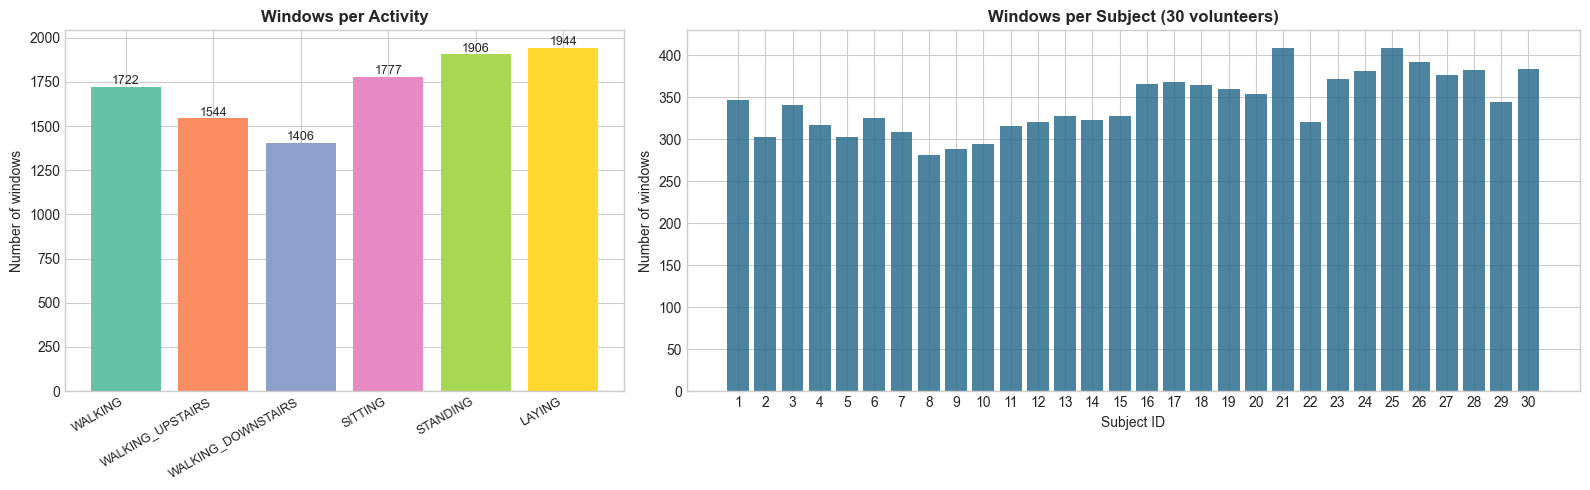

,Activity,Windows,Percentage
0,WALKING,1722,16.72
1,WALKING_UPSTAIRS,1544,14.99
2,WALKING_DOWNSTAIRS,1406,13.65
3,SITTING,1777,17.25
4,STANDING,1906,18.51
5,LAYING,1944,18.88


In [4]:
activity_order = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]
act_counts = df["activity"].value_counts().reindex(activity_order)
subj_counts = df["subject"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 1.6]})
bars = axes[0].bar(act_counts.index, act_counts.values, color=sns.color_palette("Set2", 6))
axes[0].set_title("Windows per Activity", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Number of windows")
axes[0].set_xticklabels(act_counts.index, rotation=30, ha="right", fontsize=9)
for b, v in zip(bars, act_counts.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 15, str(v), ha="center", fontsize=9)

axes[1].bar(subj_counts.index, subj_counts.values, color="#2C6E8E", alpha=0.85)
axes[1].set_title("Windows per Subject (30 volunteers)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Subject ID")
axes[1].set_ylabel("Number of windows")
axes[1].set_xticks(subj_counts.index)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "class_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

class_dist_df = pd.DataFrame({"Activity": act_counts.index, "Windows": act_counts.values,
                              "Percentage": (act_counts.values / len(df) * 100).round(2)})
class_dist_df

##### Feature distributions by activity
Plotting the distribution of a few representative features for each activity. The body acceleration standard deviation separates static and dynamic activities almost perfectly, while gravity related features separate LAYING from SITTING and STANDING.

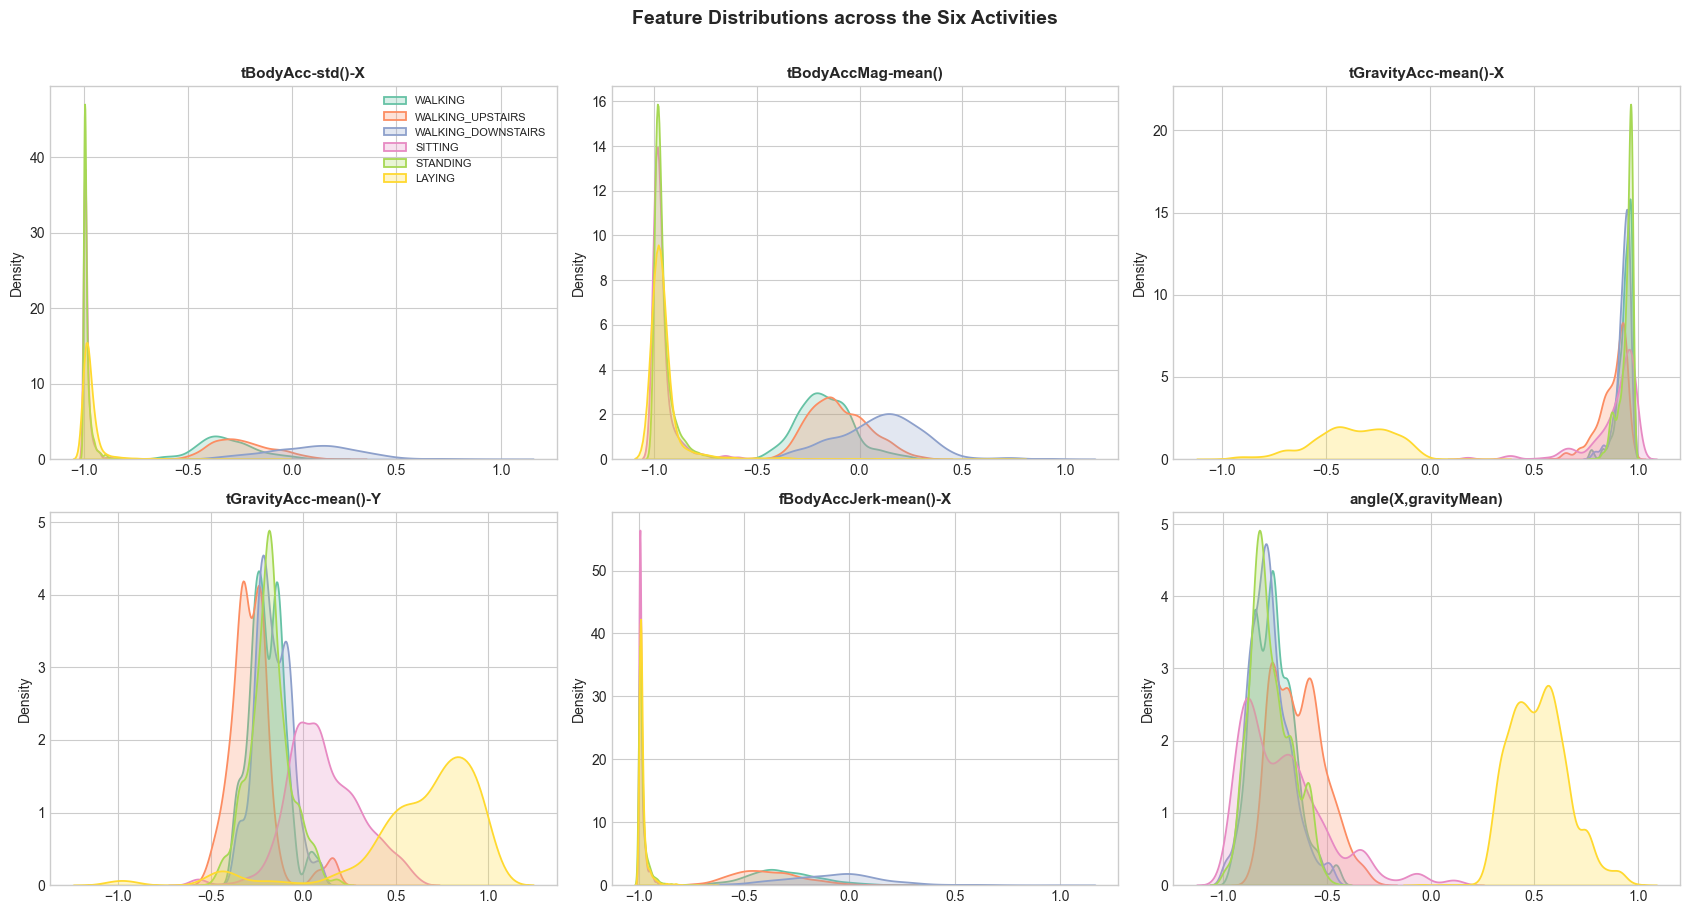

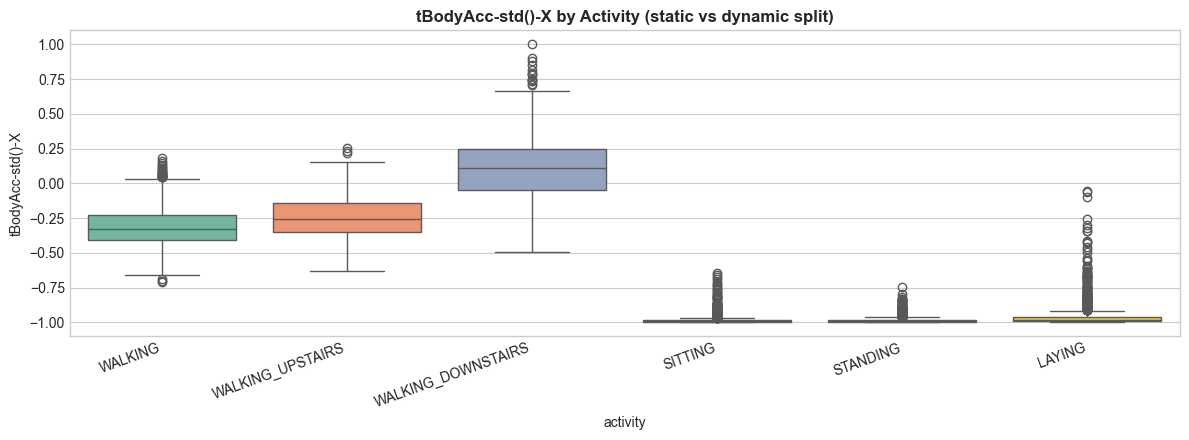

In [5]:
plot_feats = ["tBodyAcc-std()-X", "tBodyAccMag-mean()", "tGravityAcc-mean()-X",
              "tGravityAcc-mean()-Y", "fBodyAccJerk-mean()-X", "angle(X,gravityMean)"]
palette = dict(zip(activity_order, sns.color_palette("Set2", 6)))

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, feat in zip(axes.flatten(), plot_feats):
    for act in activity_order:
        sns.kdeplot(df.loc[df["activity"] == act, feat], ax=ax, label=act, color=palette[act], fill=True, alpha=0.25, linewidth=1.3)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
axes[0, 0].legend(fontsize=8)
plt.suptitle("Feature Distributions across the Six Activities", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "feature_distributions.png"), dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.boxplot(data=df, x="activity", y="tBodyAcc-std()-X", order=activity_order, palette=palette, ax=ax)
ax.set_title("tBodyAcc-std()-X by Activity (static vs dynamic split)", fontsize=12, fontweight="bold")
ax.set_xticklabels(activity_order, rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "feature_boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Correlation analysis
The 561 features are heavily redundant (means, standard deviations, energies and frequency bins of the same signals). The heatmap shows a subset of 24 mean and standard deviation features and the overall count of highly correlated pairs is printed below.

Total feature pairs: 157080
Pairs with |r| > 0.9: 8093  (5.15%)
Pairs with |r| > 0.8: 22815  (14.52%)
Mean |r| over all pairs: 0.418


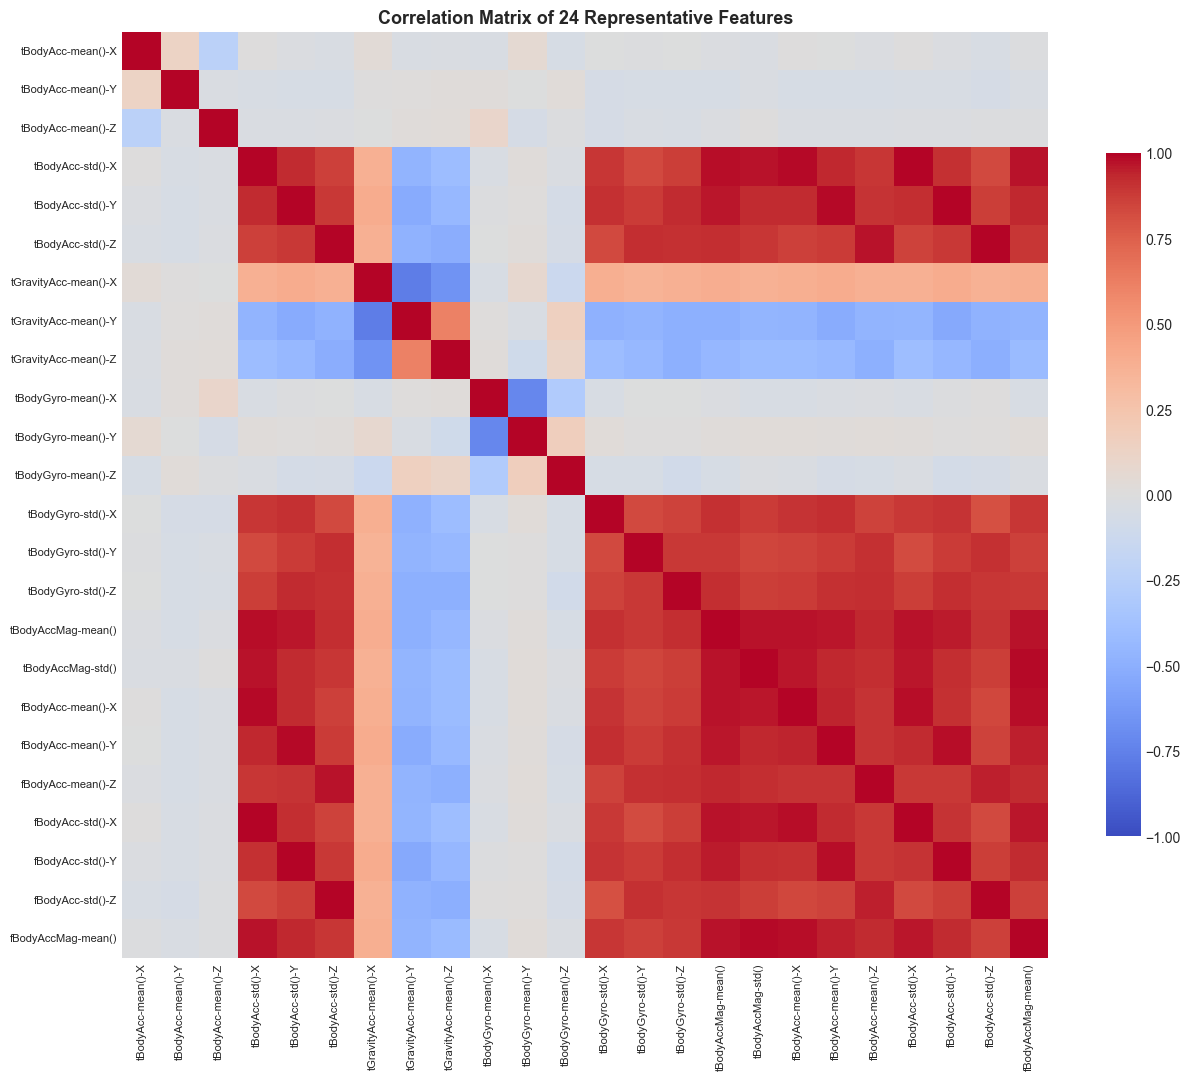

In [6]:
corr_all = np.corrcoef(X, rowvar=False)
upper = corr_all[np.triu_indices_from(corr_all, k=1)]
print(f"Total feature pairs: {len(upper)}")
print(f"Pairs with |r| > 0.9: {(np.abs(upper) > 0.9).sum()}  ({(np.abs(upper) > 0.9).mean()*100:.2f}%)")
print(f"Pairs with |r| > 0.8: {(np.abs(upper) > 0.8).sum()}  ({(np.abs(upper) > 0.8).mean()*100:.2f}%)")
print(f"Mean |r| over all pairs: {np.abs(upper).mean():.3f}")

subset = [f for f in feature_names if f.startswith(("tBodyAcc-mean()", "tBodyAcc-std()", "tGravityAcc-mean()", "tBodyGyro-mean()", "tBodyGyro-std()",
                                                    "tBodyAccMag-mean()", "tBodyAccMag-std()", "fBodyAcc-mean()", "fBodyAcc-std()", "fBodyAccMag-mean()", "fBodyGyroMag-mean()"))]
subset = subset[:24]
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(df[subset].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=ax,
            xticklabels=subset, yticklabels=subset, cbar_kws={"shrink": 0.7})
ax.set_title("Correlation Matrix of 24 Representative Features", fontsize=13, fontweight="bold")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "correlation_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Preprocessing: standardization and PCA
The dataset has no missing values and the labels are already integer coded, so the preprocessing is standardization followed by PCA. Standardizing puts every feature on the same scale so that Euclidean distances are not dominated by the few wide-range features. PCA then removes the redundancy seen in the correlation analysis. Ten principal components are used as the common working space for all three algorithms: this keeps most of the structure, makes DBSCAN's density estimates meaningful (density-based methods break down in hundreds of dimensions) and speeds up hierarchical clustering.

 Components  Cumulative Variance (%)
          2                    56.98
          5                    64.01
         10                    70.21
         20                    76.84
         50                    87.10
        100                    94.67
        104                    95.05

Working space: 10 principal components explaining 70.21% of the variance


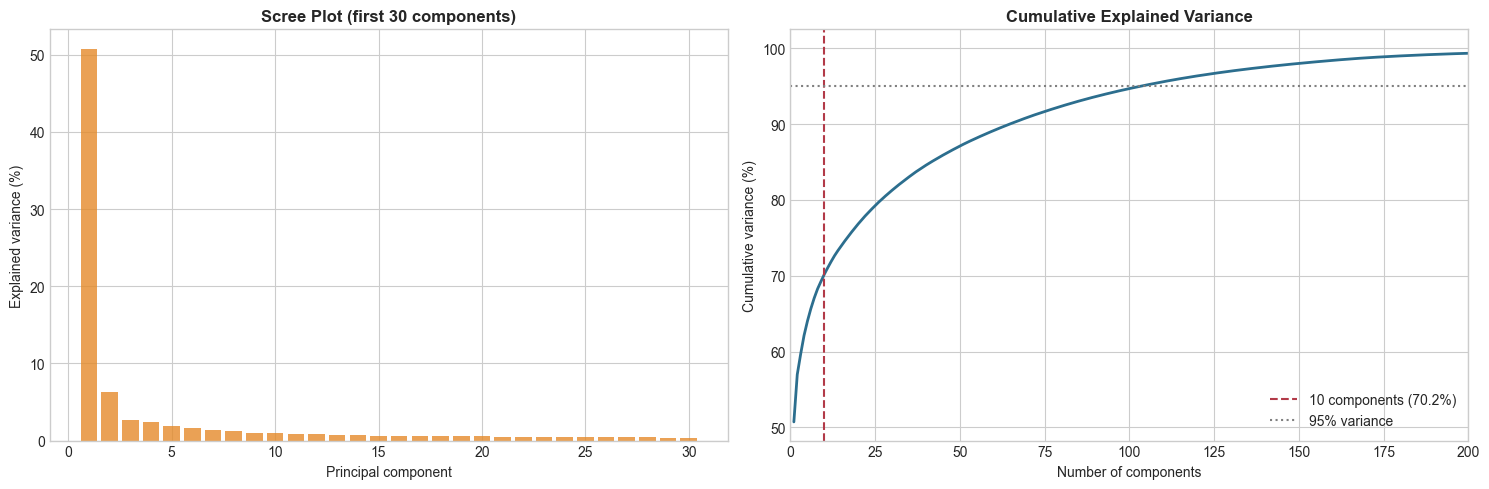

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state=RNG).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
var_table = pd.DataFrame({"Components": [2, 5, 10, 20, 50, 100, int(np.argmax(cum_var >= 0.95) + 1)],
                          "Cumulative Variance (%)": [cum_var[k - 1] * 100 for k in [2, 5, 10, 20, 50, 100, int(np.argmax(cum_var >= 0.95) + 1)]]}).round(2)
print(var_table.to_string(index=False))

N_COMPONENTS = 10
pca = PCA(n_components=N_COMPONENTS, random_state=RNG)
X_pca = pca.fit_transform(X_scaled)
print(f"\nWorking space: {N_COMPONENTS} principal components explaining {cum_var[N_COMPONENTS-1]*100:.2f}% of the variance")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(range(1, 31), pca_full.explained_variance_ratio_[:30] * 100, color="#E58A2A", alpha=0.8)
axes[0].set_title("Scree Plot (first 30 components)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance (%)")
axes[1].plot(range(1, len(cum_var) + 1), cum_var * 100, color="#2C6E8E", linewidth=2)
axes[1].axvline(N_COMPONENTS, color="#B23A48", linestyle="--", label=f"{N_COMPONENTS} components ({cum_var[N_COMPONENTS-1]*100:.1f}%)")
axes[1].axhline(95, color="gray", linestyle=":", label="95% variance")
axes[1].set_xlim(0, 200)
axes[1].set_title("Cumulative Explained Variance", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance (%)")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "pca_variance.png"), dpi=300, bbox_inches="tight")
plt.show()

##### 2D projections with the true activity labels
PCA and t-SNE projections coloured by the true activity. These give a visual reference for what a good clustering should look like: a clear gap between static and dynamic activities, with the three walking activities and SITTING/STANDING overlapping inside their groups.

t-SNE finished in 15.9 s


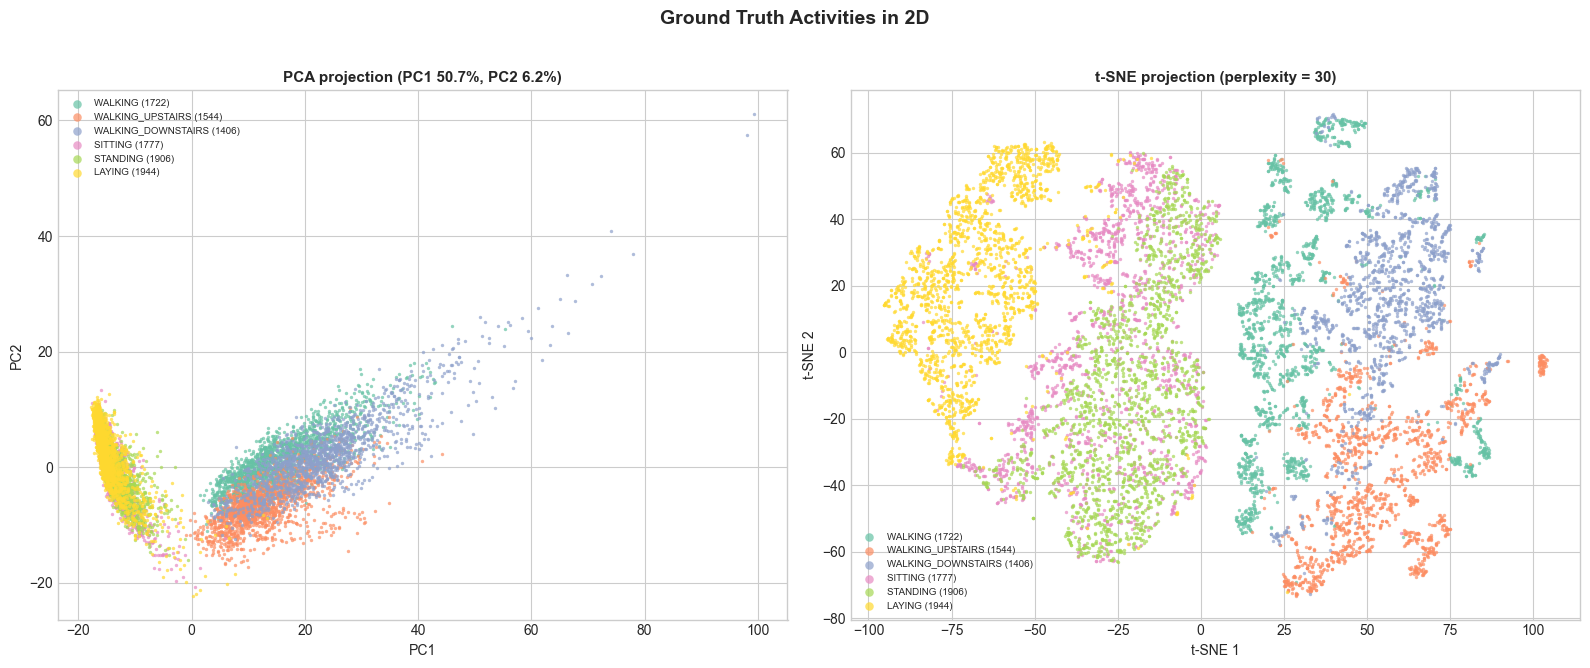

In [8]:
X_pca2 = X_pca[:, :2]
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=RNG)
X_tsne = tsne.fit_transform(X_pca)
print(f"t-SNE finished in {time.time() - t0:.1f} s")

def scatter_by_label(ax, emb, labels, title, label_names=None, cmap="Set2", noise_label=None, s=6):
    uniq = [u for u in np.unique(labels) if u != noise_label]
    colors = sns.color_palette(cmap, max(len(uniq), 3))
    for i, u in enumerate(uniq):
        m = labels == u
        name = label_names[u] if label_names is not None else f"Cluster {u}"
        ax.scatter(emb[m, 0], emb[m, 1], s=s, color=colors[i % len(colors)], label=f"{name} ({m.sum()})", alpha=0.7, linewidths=0)
    if noise_label is not None and (labels == noise_label).any():
        m = labels == noise_label
        ax.scatter(emb[m, 0], emb[m, 1], s=s, color="lightgray", label=f"Noise ({m.sum()})", alpha=0.6, linewidths=0)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=7, markerscale=2.5, loc="best")

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
scatter_by_label(axes[0], X_pca2, y, f"PCA projection (PC1 {pca.explained_variance_ratio_[0]*100:.1f}%, PC2 {pca.explained_variance_ratio_[1]*100:.1f}%)", label_names=activity_map)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
scatter_by_label(axes[1], X_tsne, y, "t-SNE projection (perplexity = 30)", label_names=activity_map)
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
plt.suptitle("Ground Truth Activities in 2D", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "projections_true_labels.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Evaluation helpers
Internal metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz) are computed in the 10-dimensional PCA space that every algorithm clusters in. External metrics (ARI, NMI) compare cluster assignments with the true activity labels. Clusters are mapped to activities with the Hungarian algorithm so that a confusion matrix and a mapped accuracy can also be reported.

In [9]:
def internal_metrics(Z, labels):
    mask = labels != -1
    k = len(np.unique(labels[mask]))
    if k < 2:
        return {"Silhouette": np.nan, "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan}
    return {"Silhouette": silhouette_score(Z[mask], labels[mask]),
            "Davies-Bouldin": davies_bouldin_score(Z[mask], labels[mask]),
            "Calinski-Harabasz": calinski_harabasz_score(Z[mask], labels[mask])}

def external_metrics(y_true, labels):
    return {"ARI": adjusted_rand_score(y_true, labels), "NMI": normalized_mutual_info_score(y_true, labels)}

def map_clusters_to_labels(y_true, labels):
    # Hungarian assignment of clusters to activities (noise points are left unmapped)
    clusters = [c for c in np.unique(labels) if c != -1]
    classes = np.unique(y_true)
    cont = np.zeros((len(clusters), len(classes)), dtype=int)
    for i, c in enumerate(clusters):
        for j, t in enumerate(classes):
            cont[i, j] = np.sum((labels == c) & (y_true == t))
    rows, cols = linear_sum_assignment(-cont)
    mapping = {clusters[r]: classes[c] for r, c in zip(rows, cols)}
    # clusters beyond the number of classes get their majority activity
    for c in clusters:
        if c not in mapping:
            mapping[c] = classes[np.argmax(cont[clusters.index(c)])]
    mapped = np.array([mapping.get(l, -1) for l in labels])
    return mapped, mapping

def evaluate(name, Z, y_true, labels):
    res = {"Algorithm": name, "Clusters": len([c for c in np.unique(labels) if c != -1]),
           "Noise (%)": (labels == -1).mean() * 100}
    res.update(internal_metrics(Z, labels))
    res.update(external_metrics(y_true, labels))
    mapped, _ = map_clusters_to_labels(y_true, labels)
    valid = mapped != -1
    res["Mapped Accuracy"] = (mapped[valid] == y_true[valid]).mean() if valid.any() else np.nan
    return res

def contingency(y_true, labels):
    ct = pd.crosstab(pd.Series(labels, name="Cluster"), pd.Series([activity_map[v] for v in y_true], name="Activity"))
    return ct[activity_order]

print("Helper functions defined.")

Helper functions defined.


##### K-Means: elbow method and silhouette analysis (Table 1)
Running K-Means for k = 2 to 8 with 10 random restarts each and recording WCSS (inertia), Silhouette score and, for a fuller picture, Davies-Bouldin, Calinski-Harabasz, ARI and NMI.

In [10]:
k_values = list(range(2, 9))
elbow_rows = []
kmeans_models = {}
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(X_pca)
    kmeans_models[k] = km
    row = {"k": k, "WCSS (Inertia)": km.inertia_}
    row.update(internal_metrics(X_pca, km.labels_))
    row.update(external_metrics(y, km.labels_))
    elbow_rows.append(row)

elbow_df = pd.DataFrame(elbow_rows)
elbow_df["WCSS drop (%)"] = -elbow_df["WCSS (Inertia)"].pct_change() * 100
elbow_df.to_csv(os.path.join(IMG_DIR, "table1_kmeans_elbow.csv"), index=False)
print("Table 1: K-Means Elbow Method Results")
elbow_df.round(4)

Table 1: K-Means Elbow Method Results


,k,WCSS (Inertia),Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,WCSS drop (%)
0,2,1.552171e+06,0.5606,0.6941,16613.2661,0.3296,0.5455,NaN
1,3,1.204169e+06,0.4734,1.0840,12193.9661,0.3314,0.5188,22.4204
2,4,1.067331e+06,0.2967,1.3725,9610.6134,0.2988,0.4698,11.3637
3,5,9.426077e+05,0.2727,1.3996,8501.4081,0.2909,0.4603,11.6855
4,6,8.665503e+05,0.2806,1.2874,7578.0515,0.4271,0.5621,8.0688
5,7,8.154514e+05,0.2733,1.2442,6817.5906,0.4140,0.5564,5.8968
6,8,7.618707e+05,0.2480,1.3754,6357.4081,0.4101,0.5438,6.5707


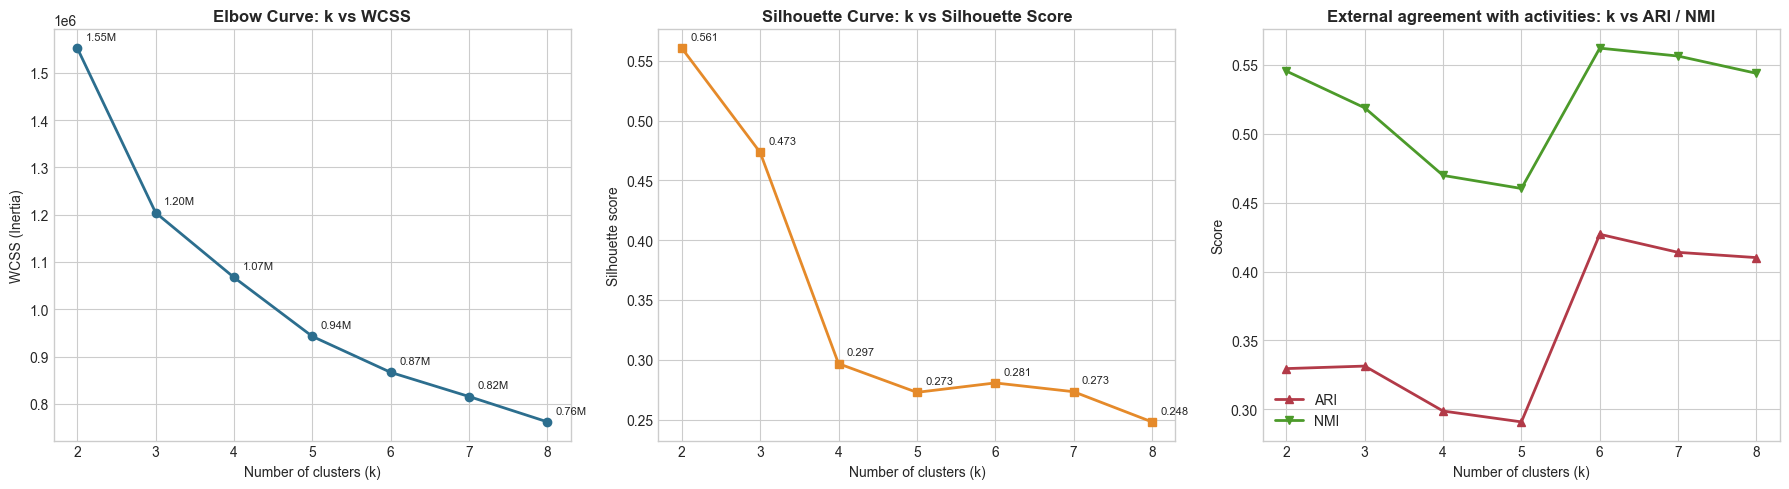

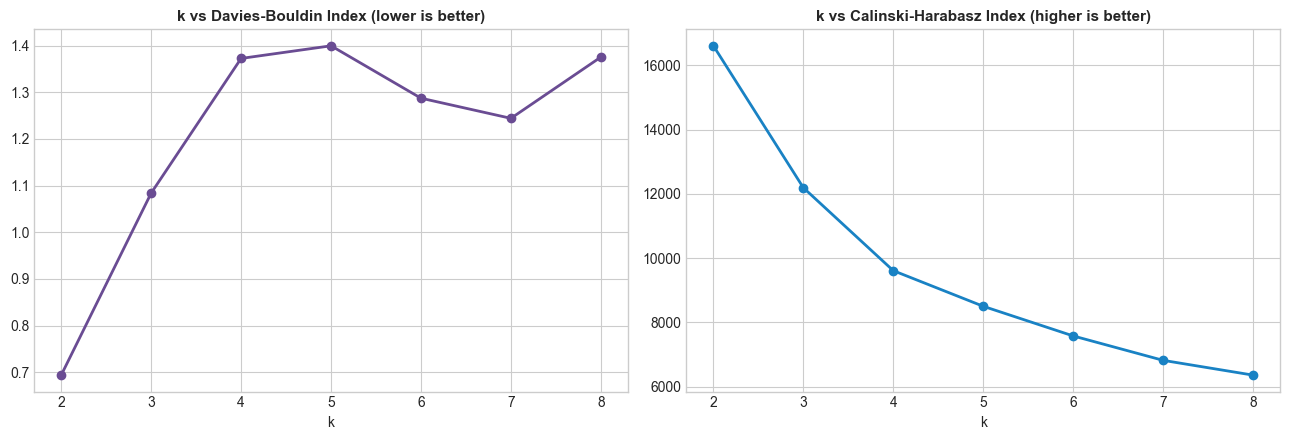

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(elbow_df["k"], elbow_df["WCSS (Inertia)"], marker="o", color="#2C6E8E", linewidth=2)
axes[0].set_title("Elbow Curve: k vs WCSS", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of clusters (k)"); axes[0].set_ylabel("WCSS (Inertia)")
for k, w in zip(elbow_df["k"], elbow_df["WCSS (Inertia)"]):
    axes[0].annotate(f"{w/1e6:.2f}M", (k, w), textcoords="offset points", xytext=(6, 6), fontsize=8)

axes[1].plot(elbow_df["k"], elbow_df["Silhouette"], marker="s", color="#E58A2A", linewidth=2)
axes[1].set_title("Silhouette Curve: k vs Silhouette Score", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of clusters (k)"); axes[1].set_ylabel("Silhouette score")
for k, s in zip(elbow_df["k"], elbow_df["Silhouette"]):
    axes[1].annotate(f"{s:.3f}", (k, s), textcoords="offset points", xytext=(6, 6), fontsize=8)

axes[2].plot(elbow_df["k"], elbow_df["ARI"], marker="^", color="#B23A48", linewidth=2, label="ARI")
axes[2].plot(elbow_df["k"], elbow_df["NMI"], marker="v", color="#4C9A2A", linewidth=2, label="NMI")
axes[2].set_title("External agreement with activities: k vs ARI / NMI", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Number of clusters (k)"); axes[2].set_ylabel("Score")
axes[2].legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "kmeans_elbow_silhouette.png"), dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(elbow_df["k"], elbow_df["Davies-Bouldin"], marker="o", color="#6A4C93", linewidth=2)
axes[0].set_title("k vs Davies-Bouldin Index (lower is better)", fontsize=11, fontweight="bold"); axes[0].set_xlabel("k")
axes[1].plot(elbow_df["k"], elbow_df["Calinski-Harabasz"], marker="o", color="#1982C4", linewidth=2)
axes[1].set_title("k vs Calinski-Harabasz Index (higher is better)", fontsize=11, fontweight="bold"); axes[1].set_xlabel("k")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "kmeans_db_ch.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Choosing k
The WCSS curve drops steeply up to k = 3 (22.4% reduction from k = 2 to 3) and flattens after k = 6, where the per-step reduction falls to about 6%. The silhouette is highest at k = 2, which is the static versus dynamic split that dominates the data, but that is a coarse solution that merges three activities on each side. Among the finer solutions the silhouette has a local peak at k = 6 (0.281 versus 0.273 at k = 5 and 7), and k = 6 also gives the best ARI and NMI. Since the elbow region, the local silhouette peak and the number of activities all point to six, k = 6 is chosen for the final K-Means model, with the k = 2 solution kept for comparison.

In [12]:
K_BEST = 6
kmeans_final = kmeans_models[K_BEST]
labels_kmeans = kmeans_final.labels_
labels_kmeans2 = kmeans_models[2].labels_

print(f"K-Means with k = {K_BEST}: cluster sizes = {np.bincount(labels_kmeans).tolist()}")
print("\nContingency table (K-Means clusters vs activities):")
ct_kmeans = contingency(y, labels_kmeans)
display(ct_kmeans)
print("\nContingency table for k = 2:")
display(contingency(y, labels_kmeans2))

# sensitivity to k: how the same activity is split/merged as k changes
print("\nK-Means sensitivity to k (ARI / NMI / Silhouette):")
print(elbow_df[["k", "Silhouette", "ARI", "NMI"]].round(4).to_string(index=False))

K-Means with k = 6: cluster sizes = [1686, 2455, 1938, 1154, 2785, 281]

Contingency table (K-Means clusters vs activities):


Activity,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
Cluster,,,,,,
0,0,0,0,118,0,1568
1,896,1236,319,1,0,3
2,749,300,889,0,0,0
3,0,2,0,391,445,316
4,0,0,0,1267,1461,57
5,77,6,198,0,0,0



Contingency table for k = 2:


Activity,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
Cluster,,,,,,
0,0,8,0,1774,1906,1932
1,1722,1536,1406,3,0,12



K-Means sensitivity to k (ARI / NMI / Silhouette):
 k  Silhouette    ARI    NMI
 2      0.5606 0.3296 0.5455
 3      0.4734 0.3314 0.5188
 4      0.2967 0.2988 0.4698
 5      0.2727 0.2909 0.4603
 6      0.2806 0.4271 0.5621
 7      0.2733 0.4140 0.5564
 8      0.2480 0.4101 0.5438


##### K-Means cluster visualization
K-Means clusters (k = 6) shown in the PCA and t-SNE projections next to the true labels.

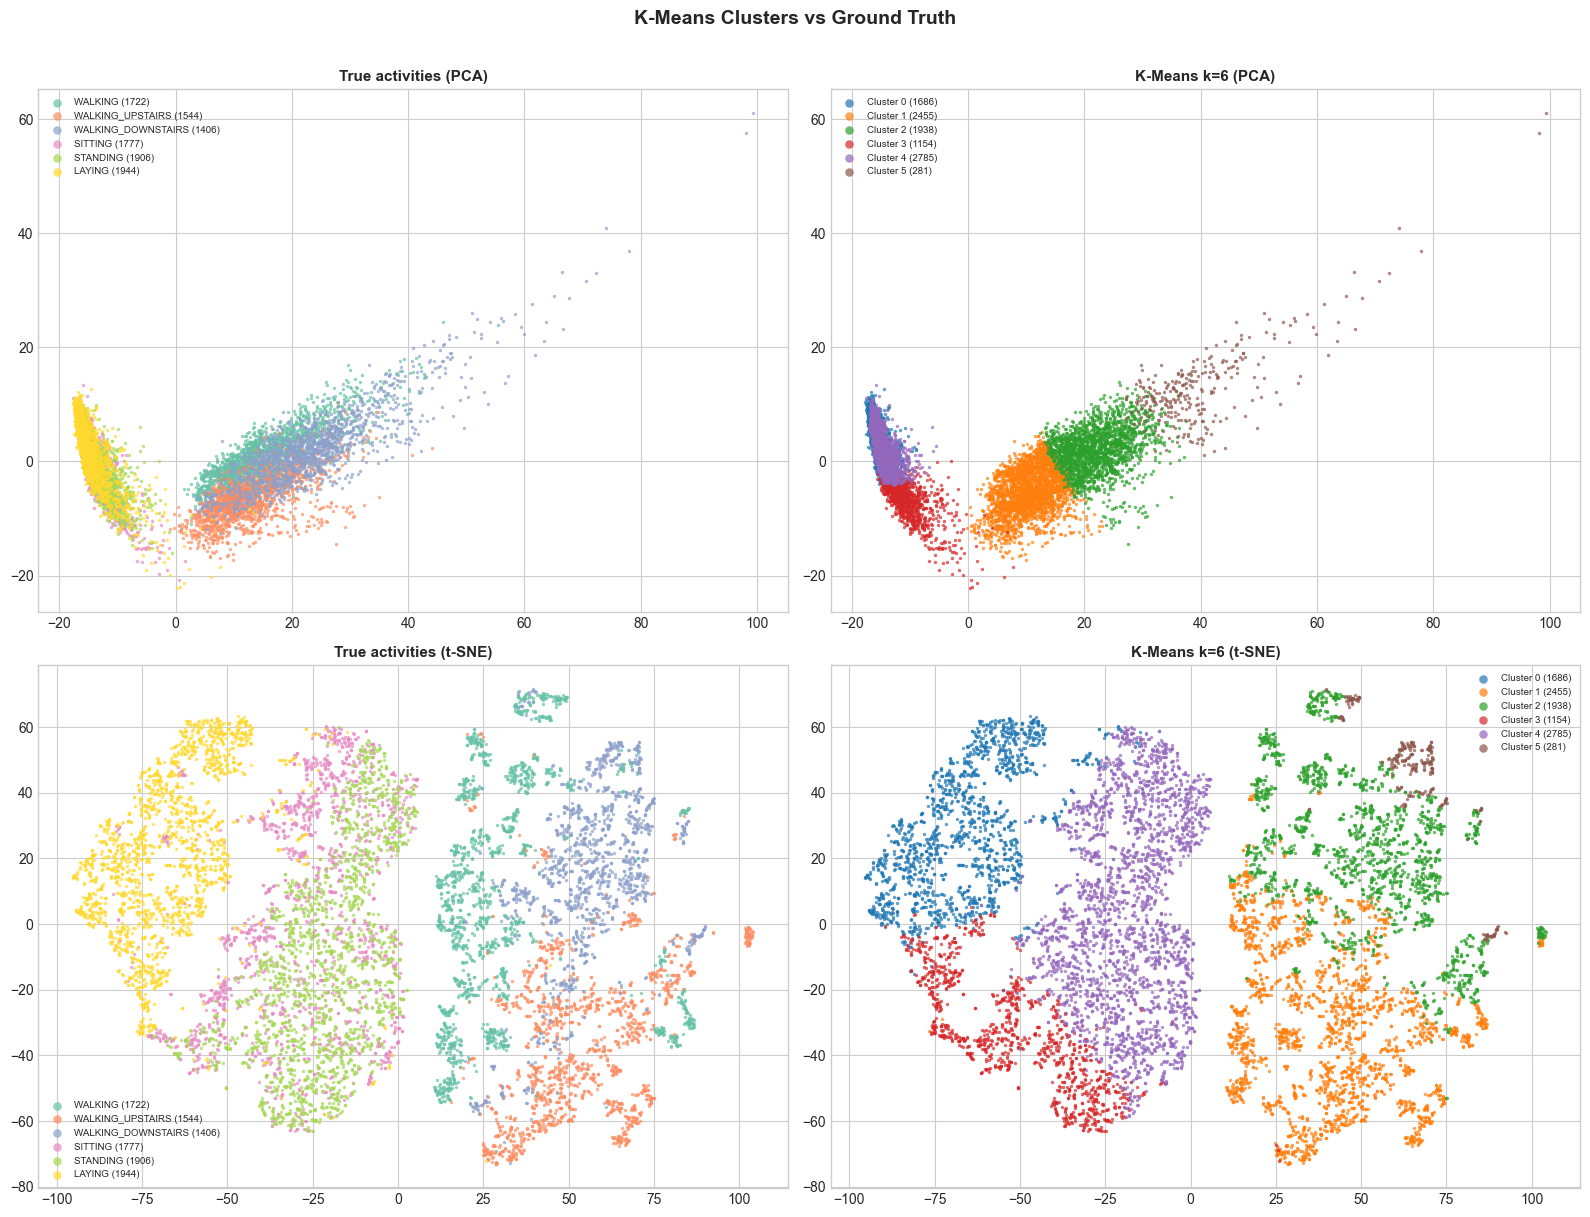

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
scatter_by_label(axes[0, 0], X_pca2, y, "True activities (PCA)", label_names=activity_map)
scatter_by_label(axes[0, 1], X_pca2, labels_kmeans, f"K-Means k={K_BEST} (PCA)", cmap="tab10")
scatter_by_label(axes[1, 0], X_tsne, y, "True activities (t-SNE)", label_names=activity_map)
scatter_by_label(axes[1, 1], X_tsne, labels_kmeans, f"K-Means k={K_BEST} (t-SNE)", cmap="tab10")
plt.suptitle("K-Means Clusters vs Ground Truth", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "kmeans_clusters.png"), dpi=300, bbox_inches="tight")
plt.show()

##### K-Means robustness: full feature space vs PCA space and random initialization
Checking that working in the 10-component PCA space does not change the K-Means solution materially, and how stable the k = 6 solution is across different random initialisations.

In [14]:
rows = []
for name, Z in [("561 standardized features", X_scaled), ("50 PCA components", PCA(n_components=50, random_state=RNG).fit_transform(X_scaled)), ("10 PCA components", X_pca)]:
    t0 = time.time()
    km = KMeans(n_clusters=K_BEST, n_init=10, random_state=RNG).fit(Z)
    r = {"Feature space": name, "Dimensions": Z.shape[1], "Time (s)": time.time() - t0}
    r.update(internal_metrics(Z, km.labels_)); r.update(external_metrics(y, km.labels_))
    rows.append(r)
space_df = pd.DataFrame(rows).round(4)
print("K-Means (k = 6) in different feature spaces:")
display(space_df)

seed_rows = []
for seed in range(10):
    km = KMeans(n_clusters=K_BEST, n_init=1, random_state=seed).fit(X_pca)
    seed_rows.append({"seed": seed, "WCSS": km.inertia_, "Silhouette": silhouette_score(X_pca, km.labels_),
                      "ARI": adjusted_rand_score(y, km.labels_), "ARI vs final": adjusted_rand_score(labels_kmeans, km.labels_)})
seed_df = pd.DataFrame(seed_rows)
print("\nK-Means (k = 6) with single random initialisations:")
print(seed_df.round(4).to_string(index=False))
print(f"\nWCSS range across seeds: {seed_df['WCSS'].min():.0f} to {seed_df['WCSS'].max():.0f}; ARI range: {seed_df['ARI'].min():.3f} to {seed_df['ARI'].max():.3f}")

K-Means (k = 6) in different feature spaces:


,Feature space,Dimensions,Time (s),Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,561 standardized features,561,0.7309,0.1099,2.3836,2556.5419,0.4196,0.5593
1,50 PCA components,50,0.1484,0.1524,1.9681,3591.2853,0.4201,0.5598
2,10 PCA components,10,0.1010,0.2806,1.2874,7578.0515,0.4271,0.5621



K-Means (k = 6) with single random initialisations:
 seed        WCSS  Silhouette    ARI  ARI vs final
    0 888614.4546      0.2380 0.2882        0.4814
    1 866581.0497      0.2793 0.4270        0.9918
    2 889786.6615      0.2619 0.2854        0.5811
    3 866577.9728      0.2793 0.4269        0.9904
    4 866555.8248      0.2785 0.4241        0.9763
    5 866550.4894      0.2807 0.4269        0.9995
    6 887835.0450      0.2287 0.3016        0.4747
    7 887790.9132      0.2298 0.3028        0.4747
    8 889786.3831      0.2611 0.2846        0.5781
    9 877913.3833      0.2645 0.3491        0.6859

WCSS range across seeds: 866550 to 889787; ARI range: 0.285 to 0.427


##### DBSCAN: choosing eps with the k-distance plot
For a given min_samples, the sorted distance of every point to its min_samples-th nearest neighbour shows where density drops. The knee of this curve is the usual starting point for eps. The same plot on the full 561-dimensional space shows why DBSCAN is run in the PCA space: in high dimensions all neighbour distances are large and similar, so there is no density contrast for DBSCAN to work with.

k-distance percentiles (k = 10) in the 10-D PCA space: {50: np.float64(3.37), 80: np.float64(5.01), 90: np.float64(6.03), 95: np.float64(7.15)}
k-distance percentiles (k = 10) in the 561-D space:    {50: np.float64(13.07), 80: np.float64(16.95), 90: np.float64(19.29), 95: np.float64(22.13)}
Ratio of max to min k-distance: PCA-10 = 61.8, full = 11.7


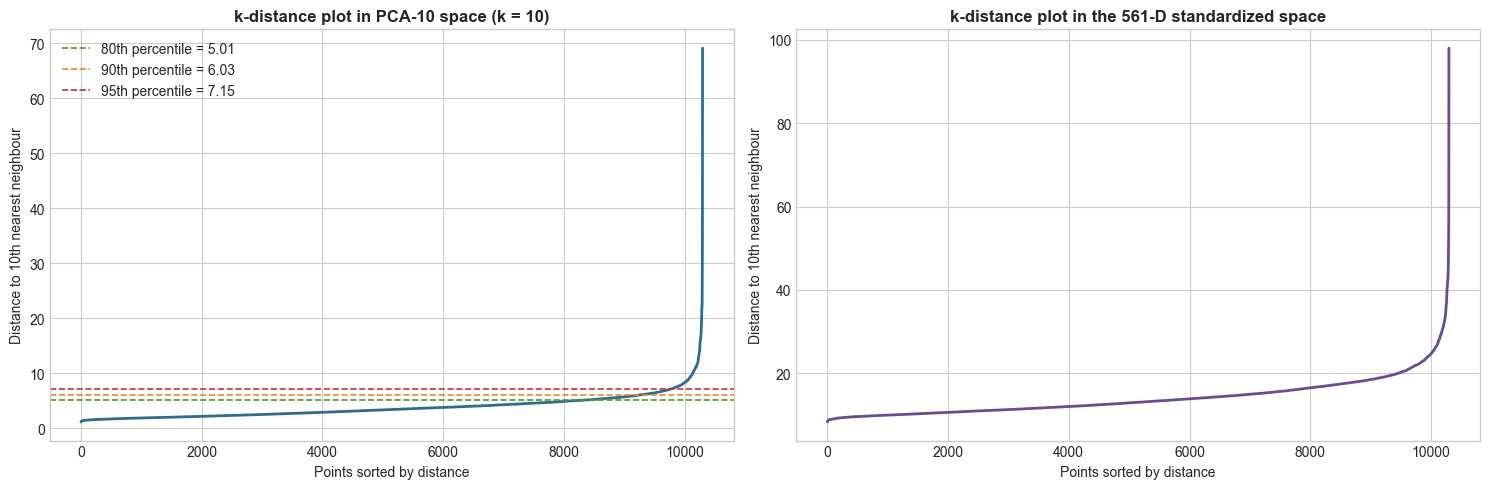

561-D space, eps = 13.07: clusters = 12, noise = 38.5%


561-D space, eps = 19.29: clusters = 1, noise = 5.7%


561-D space, eps = 22.13: clusters = 1, noise = 2.8%


In [15]:
MIN_SAMPLES_REF = 10
def k_distances(Z, k):
    nn = NearestNeighbors(n_neighbors=k).fit(Z)
    d, _ = nn.kneighbors(Z)
    return np.sort(d[:, -1])

kd_pca = k_distances(X_pca, MIN_SAMPLES_REF)
kd_full = k_distances(X_scaled, MIN_SAMPLES_REF)
pct = [50, 80, 90, 95]
print("k-distance percentiles (k = 10) in the 10-D PCA space:", dict(zip(pct, np.percentile(kd_pca, pct).round(2))))
print("k-distance percentiles (k = 10) in the 561-D space:   ", dict(zip(pct, np.percentile(kd_full, pct).round(2))))
print(f"Ratio of max to min k-distance: PCA-10 = {kd_pca.max()/kd_pca.min():.1f}, full = {kd_full.max()/kd_full.min():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(kd_pca, color="#2C6E8E", linewidth=2)
for p, c in zip([80, 90, 95], ["#4C9A2A", "#E58A2A", "#B23A48"]):
    v = np.percentile(kd_pca, p)
    axes[0].axhline(v, color=c, linestyle="--", linewidth=1.2, label=f"{p}th percentile = {v:.2f}")
axes[0].set_title("k-distance plot in PCA-10 space (k = 10)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Points sorted by distance"); axes[0].set_ylabel("Distance to 10th nearest neighbour")
axes[0].legend()
axes[1].plot(kd_full, color="#6A4C93", linewidth=2)
axes[1].set_title("k-distance plot in the 561-D standardized space", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Points sorted by distance"); axes[1].set_ylabel("Distance to 10th nearest neighbour")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "dbscan_kdistance.png"), dpi=300, bbox_inches="tight")
plt.show()

# what DBSCAN does in the full space
for eps in np.percentile(kd_full, [50, 90, 95]):
    lab = DBSCAN(eps=eps, min_samples=MIN_SAMPLES_REF).fit(X_scaled).labels_
    print(f"561-D space, eps = {eps:.2f}: clusters = {len(set(lab)) - (1 if -1 in lab else 0)}, noise = {(lab == -1).mean()*100:.1f}%")

##### DBSCAN: tuning eps and min_samples
A grid over eps (spanning the knee region of the k-distance plot) and min_samples. The silhouette is computed on the non-noise points. The chosen configuration is the one with the highest silhouette among settings that keep noise below 10% and produce at least three clusters, so that the choice does not rely on the ground truth labels.

DBSCAN tuning grid:


,eps,min_samples,Clusters,Noise (%),Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,2.5,5,53,52.5876,-0.1814,1.0725,105.7778,0.1857,0.3309
1,2.5,10,12,59.8990,-0.0626,1.0229,126.4713,0.1519,0.2858
2,2.5,20,1,66.2977,NaN,NaN,NaN,0.1110,0.2343
3,3.0,5,45,38.6154,-0.0132,1.1858,314.6187,0.2399,0.3880
4,3.0,10,19,47.8784,0.5139,1.1136,382.5477,0.2183,0.3725
5,3.0,20,4,55.3937,0.5714,0.7700,468.3307,0.1946,0.3324
6,3.5,5,30,27.4104,0.2101,0.9614,619.0764,0.2931,0.4409
7,3.5,10,10,34.9451,0.4431,1.0241,1485.4912,0.2655,0.4134
8,3.5,20,9,44.5480,0.5207,1.1797,984.9277,0.2394,0.4017
9,4.0,5,30,18.0794,0.1654,0.9294,707.5188,0.3082,0.4558



Selected: eps = 6.0, min_samples = 20  ->  3 clusters, noise = 8.06%, silhouette = 0.5614, ARI = 0.3210, NMI = 0.4996


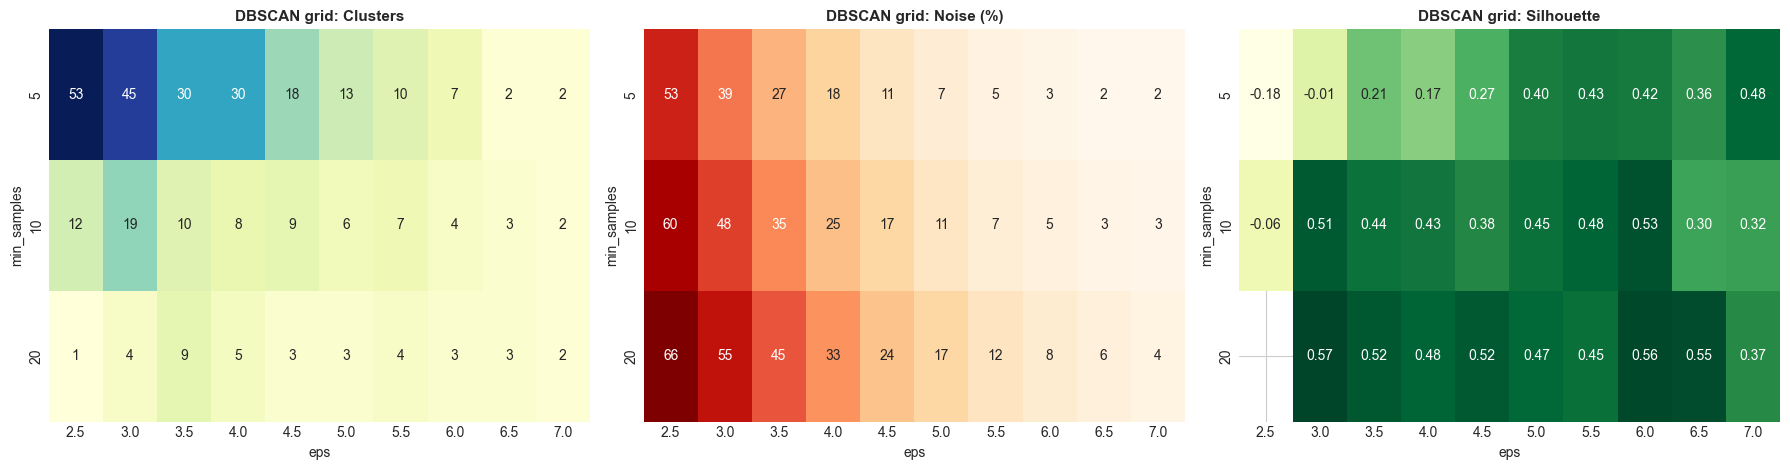

In [16]:
eps_grid = [2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
ms_grid = [5, 10, 20]
db_rows = []
for eps in eps_grid:
    for ms in ms_grid:
        lab = DBSCAN(eps=eps, min_samples=ms).fit(X_pca).labels_
        r = {"eps": eps, "min_samples": ms, "Clusters": len(set(lab)) - (1 if -1 in lab else 0), "Noise (%)": (lab == -1).mean() * 100}
        r.update(internal_metrics(X_pca, lab)); r.update(external_metrics(y, lab))
        db_rows.append(r)
db_grid = pd.DataFrame(db_rows)
db_grid.to_csv(os.path.join(IMG_DIR, "dbscan_grid.csv"), index=False)
print("DBSCAN tuning grid:")
display(db_grid.round(4))

cand = db_grid[(db_grid["Noise (%)"] < 10) & (db_grid["Clusters"] >= 3)].sort_values("Silhouette", ascending=False)
best_db = cand.iloc[0]
EPS_BEST, MS_BEST = float(best_db["eps"]), int(best_db["min_samples"])
print(f"\nSelected: eps = {EPS_BEST}, min_samples = {MS_BEST}  ->  {int(best_db['Clusters'])} clusters, noise = {best_db['Noise (%)']:.2f}%, silhouette = {best_db['Silhouette']:.4f}, ARI = {best_db['ARI']:.4f}, NMI = {best_db['NMI']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, col, cmap in zip(axes, ["Clusters", "Noise (%)", "Silhouette"], ["YlGnBu", "OrRd", "YlGn"]):
    piv = db_grid.pivot(index="min_samples", columns="eps", values=col)
    sns.heatmap(piv, annot=True, fmt=".0f" if col != "Silhouette" else ".2f", cmap=cmap, ax=ax, cbar=False)
    ax.set_title(f"DBSCAN grid: {col}", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "dbscan_grid.png"), dpi=300, bbox_inches="tight")
plt.show()

##### DBSCAN: final model and cluster visualization
Fitting DBSCAN with the selected parameters, listing the cluster sizes and showing the clusters with noise points in grey.

DBSCAN eps = 6.0, min_samples = 20
Core points: 8545, border points: 924, noise points: 830
Cluster sizes (-1 = noise):
-1     830
 0    5520
 1    3915
 2      34

Contingency table (DBSCAN clusters vs activities):


Activity,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
Cluster,,,,,,
-1,199,110,414,34,16,57
0,0,0,0,1743,1890,1887
1,1523,1400,992,0,0,0
2,0,34,0,0,0,0


Noise points per activity:
WALKING               199
WALKING_UPSTAIRS      110
WALKING_DOWNSTAIRS    414
SITTING                34
STANDING               16
LAYING                 57


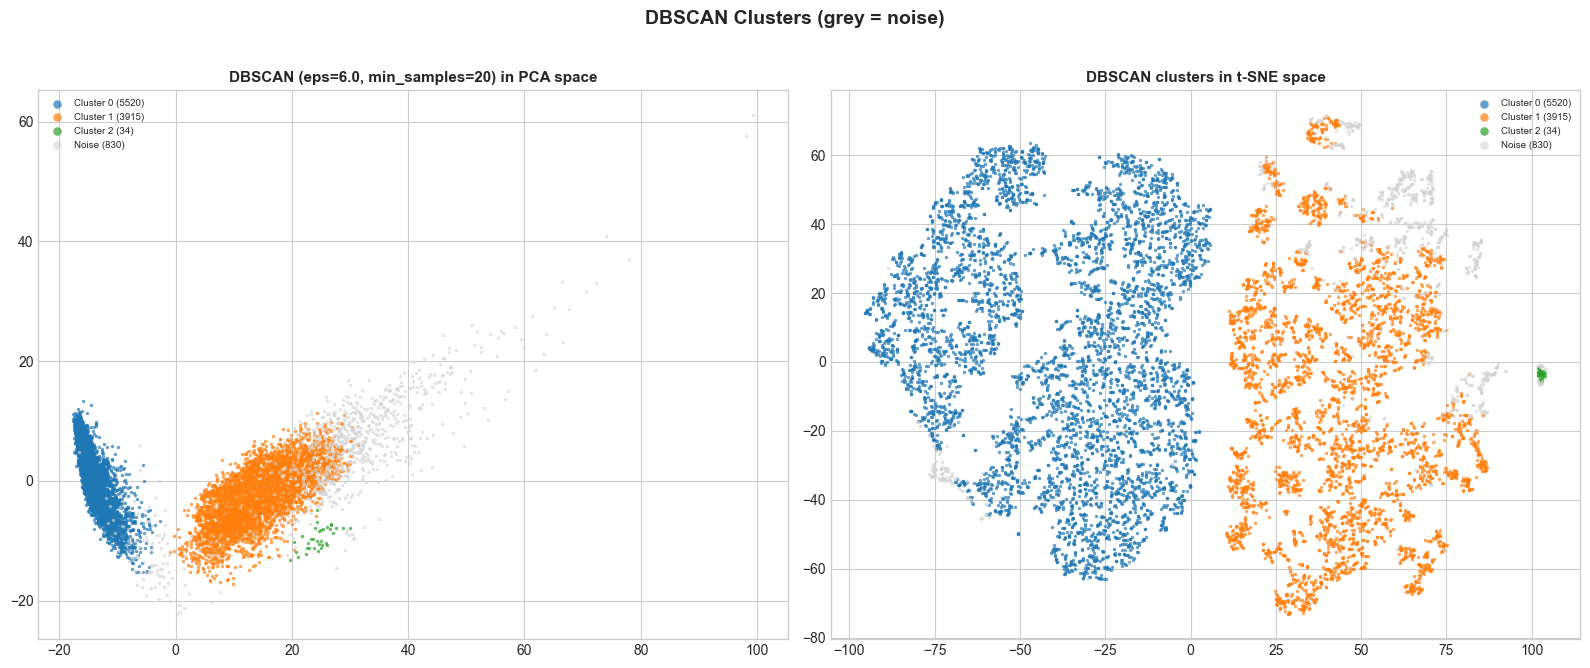

In [17]:
dbscan_final = DBSCAN(eps=EPS_BEST, min_samples=MS_BEST).fit(X_pca)
labels_dbscan = dbscan_final.labels_
n_core = len(dbscan_final.core_sample_indices_)
sizes = pd.Series(labels_dbscan).value_counts().sort_index()
print(f"DBSCAN eps = {EPS_BEST}, min_samples = {MS_BEST}")
print(f"Core points: {n_core}, border points: {(labels_dbscan != -1).sum() - n_core}, noise points: {(labels_dbscan == -1).sum()}")
print("Cluster sizes (-1 = noise):")
print(sizes.to_string())
print("\nContingency table (DBSCAN clusters vs activities):")
display(contingency(y, labels_dbscan))

noise_by_act = pd.Series([activity_map[v] for v in y[labels_dbscan == -1]]).value_counts().reindex(activity_order).fillna(0).astype(int)
print("Noise points per activity:")
print(noise_by_act.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
scatter_by_label(axes[0], X_pca2, labels_dbscan, f"DBSCAN (eps={EPS_BEST}, min_samples={MS_BEST}) in PCA space", cmap="tab10", noise_label=-1)
scatter_by_label(axes[1], X_tsne, labels_dbscan, "DBSCAN clusters in t-SNE space", cmap="tab10", noise_label=-1)
plt.suptitle("DBSCAN Clusters (grey = noise)", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "dbscan_clusters.png"), dpi=300, bbox_inches="tight")
plt.show()

##### DBSCAN: a finer alternative setting
The selected setting recovers the two dense groups. A smaller eps (5.5, min_samples = 10) is also kept as an alternative to see whether DBSCAN can split the groups further when it is pushed towards more clusters while keeping noise under 10%.

In [18]:
EPS_ALT, MS_ALT = 5.5, 10
labels_dbscan_alt = DBSCAN(eps=EPS_ALT, min_samples=MS_ALT).fit(X_pca).labels_
print(f"DBSCAN eps = {EPS_ALT}, min_samples = {MS_ALT}: clusters = {len(set(labels_dbscan_alt)) - 1}, noise = {(labels_dbscan_alt == -1).mean()*100:.2f}%")
print("Cluster sizes (-1 = noise):", pd.Series(labels_dbscan_alt).value_counts().sort_index().to_dict())
print("\nContingency table (alternative DBSCAN vs activities):")
display(contingency(y, labels_dbscan_alt))

DBSCAN eps = 5.5, min_samples = 10: clusters = 7, noise = 7.14%
Cluster sizes (-1 = noise): {-1: 735, 0: 5521, 1: 3956, 2: 10, 3: 16, 4: 39, 5: 12, 6: 10}

Contingency table (alternative DBSCAN vs activities):


Activity,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
Cluster,,,,,,
-1,135,96,398,36,14,56
0,0,0,0,1741,1892,1888
1,1559,1409,988,0,0,0
2,0,0,10,0,0,0
3,16,0,0,0,0,0
4,0,39,0,0,0,0
5,12,0,0,0,0,0
6,0,0,10,0,0,0


##### Hierarchical clustering: Ward linkage and dendrogram
Agglomerative clustering with Ward's linkage on all 10,299 windows. The dendrogram is truncated to the last 30 merges for readability, and the cut giving six clusters is marked.

Ward linkage on 10299 points computed in 1.1 s
Cut height for 6 clusters: 393.49
Ward cluster sizes: [1717, 565, 3344, 2113, 161, 2399]


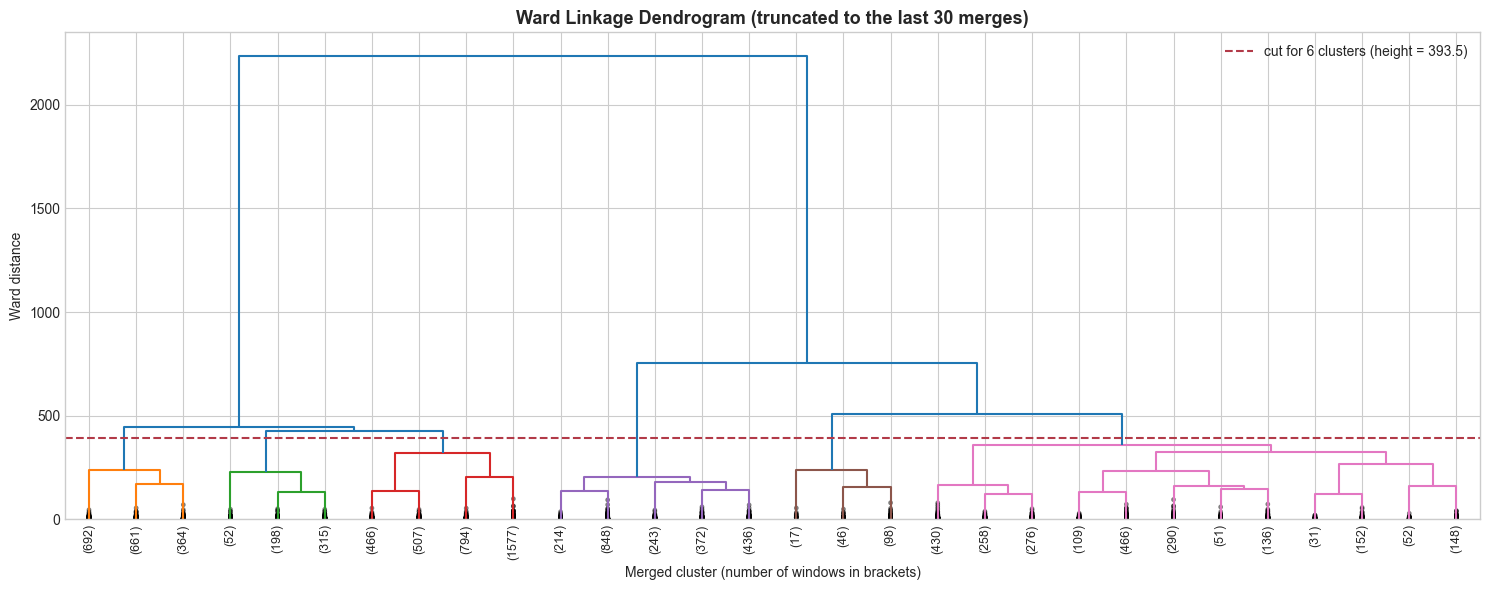

Merge heights of the last merges (large gaps indicate natural cuts):
 Number of clusters  Merge height  Gap to next
                  2       2236.43      1482.91
                  3        753.52       246.16
                  4        507.36        60.06
                  5        447.30        20.78
                  6        426.52        66.07
                  7        360.45        33.16
                  8        327.29         8.92
                  9        318.37        53.16
                 10        265.21        28.20
                 11        237.01          NaN


In [19]:
t0 = time.time()
Z_ward = linkage(X_pca, method="ward")
print(f"Ward linkage on {X_pca.shape[0]} points computed in {time.time() - t0:.1f} s")

labels_hac = fcluster(Z_ward, t=K_BEST, criterion="maxclust") - 1
# distance threshold that produces exactly K_BEST clusters (midpoint between the relevant merge heights)
cut_height = (Z_ward[-K_BEST, 2] + Z_ward[-K_BEST + 1, 2]) / 2
print(f"Cut height for {K_BEST} clusters: {cut_height:.2f}")
print(f"Ward cluster sizes: {np.bincount(labels_hac).tolist()}")

fig, ax = plt.subplots(figsize=(15, 6))
dendrogram(Z_ward, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9, show_contracted=True, color_threshold=cut_height, ax=ax)
ax.axhline(cut_height, color="#B23A48", linestyle="--", linewidth=1.5, label=f"cut for {K_BEST} clusters (height = {cut_height:.1f})")
ax.set_title("Ward Linkage Dendrogram (truncated to the last 30 merges)", fontsize=13, fontweight="bold")
ax.set_xlabel("Merged cluster (number of windows in brackets)")
ax.set_ylabel("Ward distance")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "hac_dendrogram.png"), dpi=300, bbox_inches="tight")
plt.show()

# merge heights of the last merges: a large jump suggests a natural number of clusters
last_heights = Z_ward[-10:, 2][::-1]
gap_df = pd.DataFrame({"Number of clusters": np.arange(2, 12), "Merge height": last_heights,
                       "Gap to next": np.append(last_heights[:-1] - last_heights[1:], np.nan)}).round(2)
print("Merge heights of the last merges (large gaps indicate natural cuts):")
print(gap_df.to_string(index=False))

##### Hierarchical clustering: effect of linkage criterion
Comparing single, complete, average and Ward linkage at six clusters. Single and average linkage suffer from chaining and produce one giant cluster with a few tiny ones, so their silhouette values are misleadingly high.

Agglomerative clustering with different linkage criteria (6 clusters):


,Linkage,Time (s),Cluster sizes,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,ward,1.1127,"[3344, 2399, 2113, 1717, 565, 161]",0.2626,1.3053,6712.6189,0.4897,0.6096
1,complete,1.0959,"[9912, 181, 101, 97, 6, 2]",0.2076,1.0586,379.2822,0.0036,0.0416
2,average,1.2103,"[5573, 4545, 108, 50, 21, 2]",0.5327,0.8401,4433.3434,0.3296,0.5425
3,single,0.1971,"[10293, 2, 1, 1, 1, 1]",0.3701,0.3107,31.8551,0.0001,0.0013


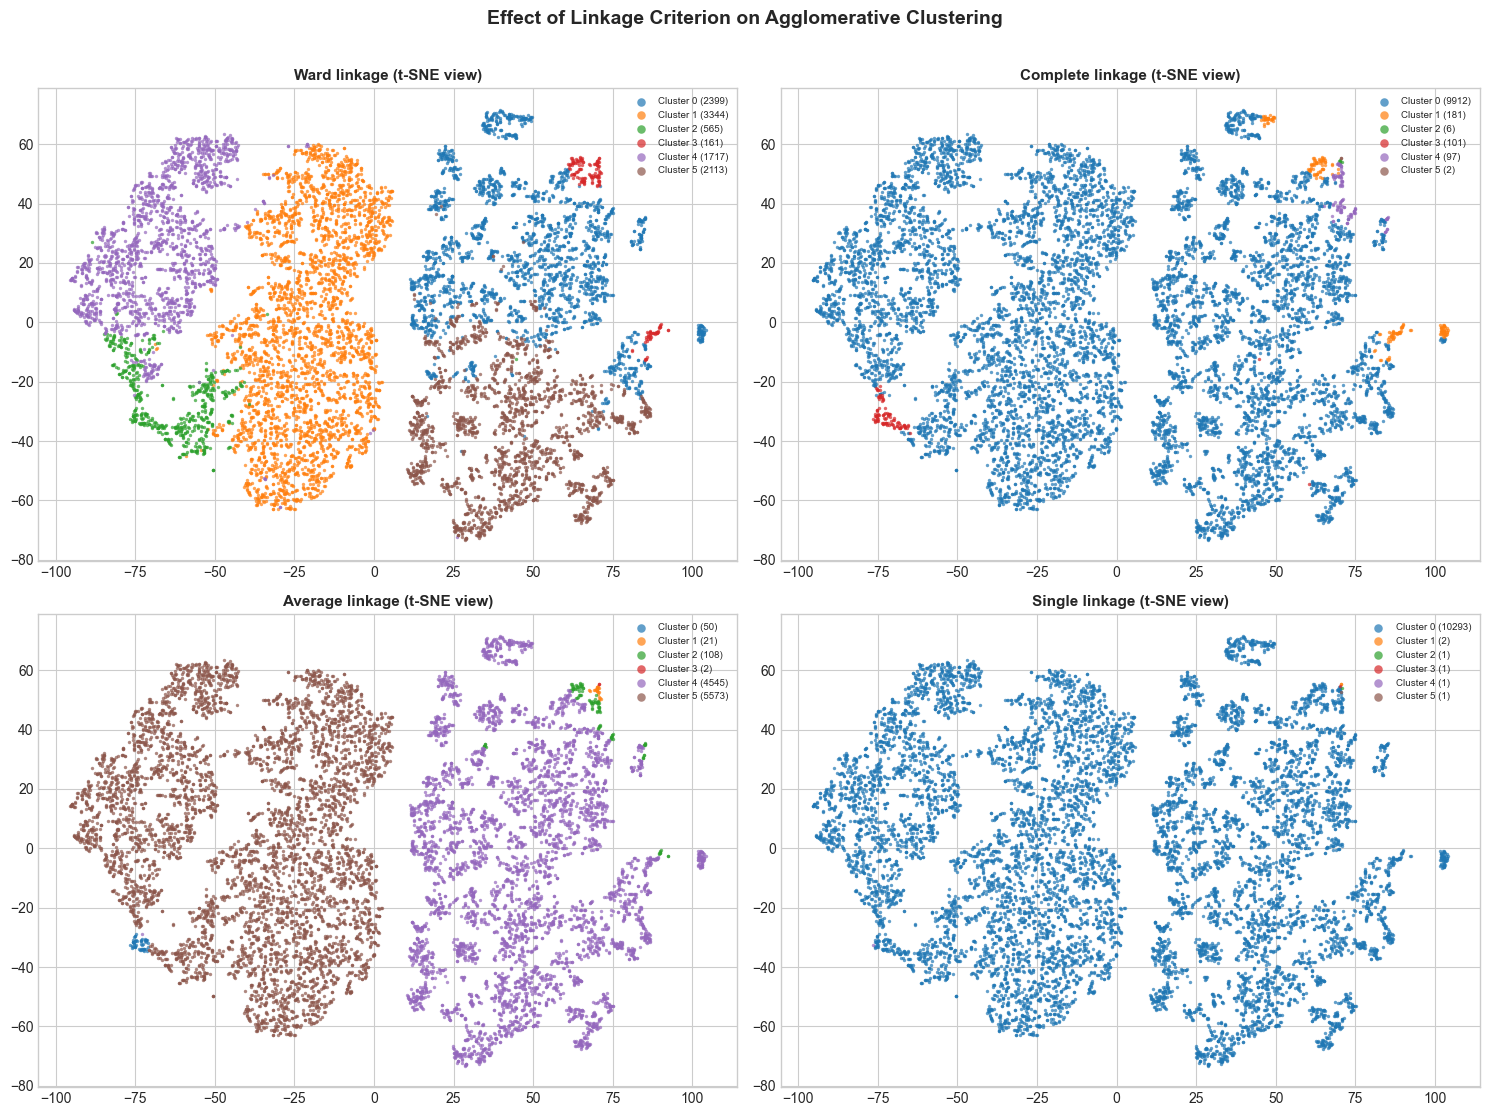

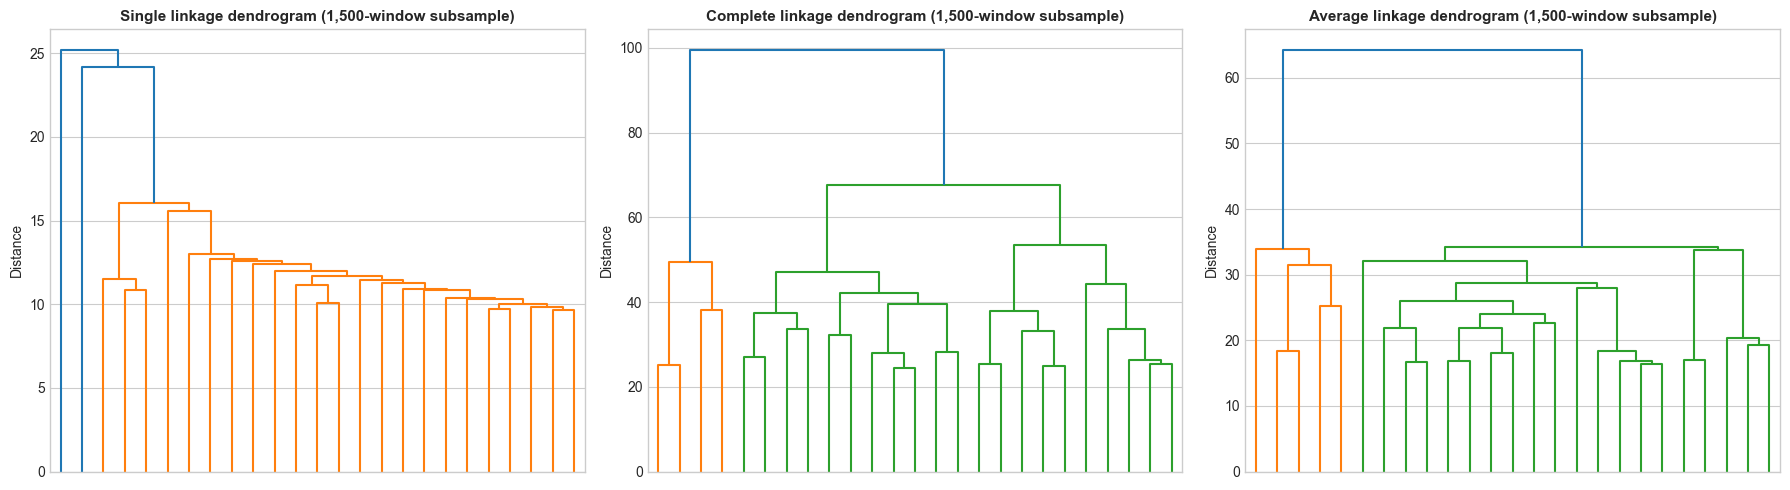

In [20]:
link_rows = []
link_labels = {}
for method in ["ward", "complete", "average", "single"]:
    t0 = time.time()
    lab = AgglomerativeClustering(n_clusters=K_BEST, linkage=method).fit(X_pca).labels_
    link_labels[method] = lab
    r = {"Linkage": method, "Time (s)": time.time() - t0, "Cluster sizes": str(sorted(np.bincount(lab).tolist(), reverse=True))}
    r.update(internal_metrics(X_pca, lab)); r.update(external_metrics(y, lab))
    link_rows.append(r)
link_df = pd.DataFrame(link_rows)
link_df.to_csv(os.path.join(IMG_DIR, "hac_linkage_comparison.csv"), index=False)
print("Agglomerative clustering with different linkage criteria (6 clusters):")
display(link_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for ax, method in zip(axes.flatten(), ["ward", "complete", "average", "single"]):
    scatter_by_label(ax, X_tsne, link_labels[method], f"{method.capitalize()} linkage (t-SNE view)", cmap="tab10")
plt.suptitle("Effect of Linkage Criterion on Agglomerative Clustering", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "hac_linkage_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

# dendrograms for the other linkages on a stratified subsample for readability
rng = np.random.RandomState(RNG)
sub_idx = np.concatenate([rng.choice(np.where(y == c)[0], 250, replace=False) for c in np.unique(y)])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, method in zip(axes, ["single", "complete", "average"]):
    Zs = linkage(X_pca[sub_idx], method=method)
    dendrogram(Zs, truncate_mode="lastp", p=25, no_labels=True, ax=ax)
    ax.set_title(f"{method.capitalize()} linkage dendrogram (1,500-window subsample)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "hac_dendrograms_other_linkages.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Hierarchical clustering: Ward clusters and contingency table

Contingency table (Ward clusters vs activities):


Activity,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
Cluster,,,,,,
0,0,0,0,76,0,1641
1,0,0,0,243,109,213
2,0,0,0,1457,1797,90
3,628,1259,225,1,0,0
4,22,13,126,0,0,0
5,1072,272,1055,0,0,0


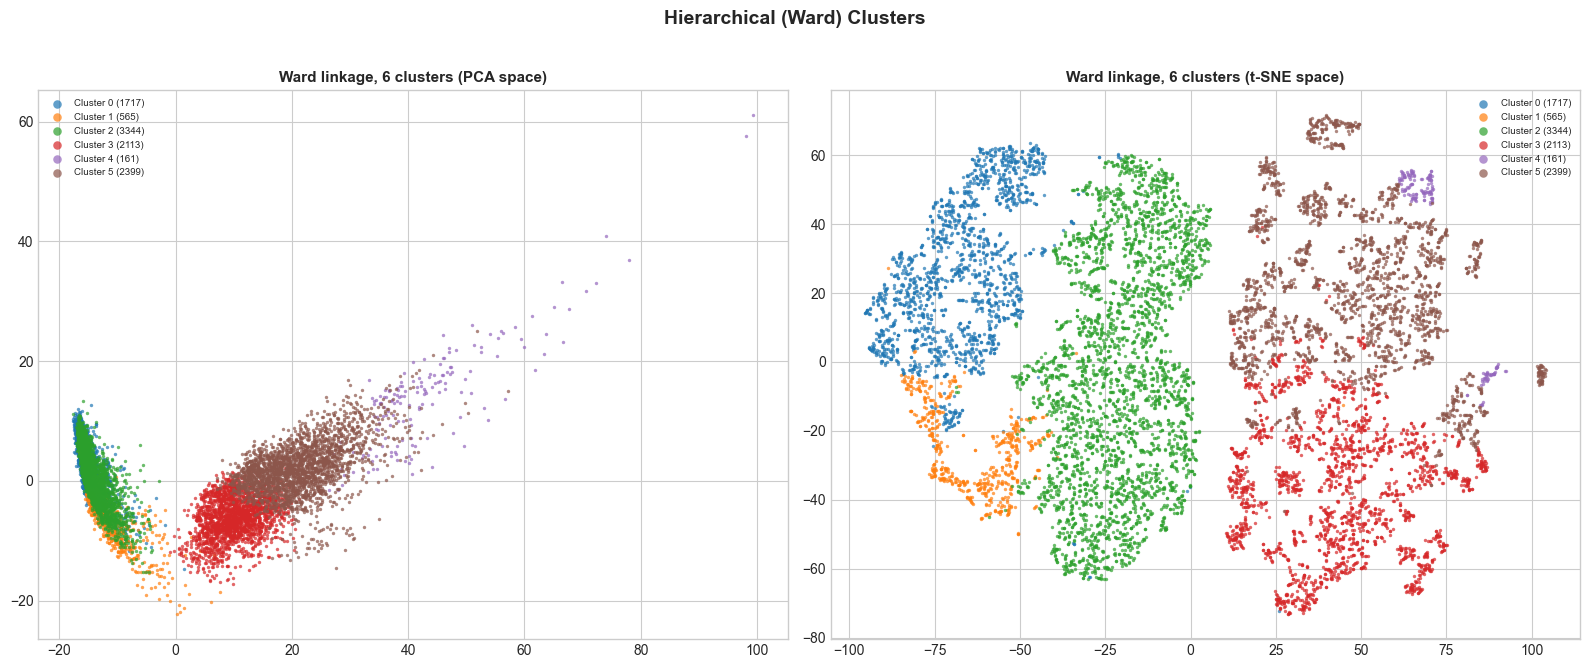

In [21]:
print("Contingency table (Ward clusters vs activities):")
display(contingency(y, labels_hac))

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
scatter_by_label(axes[0], X_pca2, labels_hac, f"Ward linkage, {K_BEST} clusters (PCA space)", cmap="tab10")
scatter_by_label(axes[1], X_tsne, labels_hac, f"Ward linkage, {K_BEST} clusters (t-SNE space)", cmap="tab10")
plt.suptitle("Hierarchical (Ward) Clusters", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "hac_clusters.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Comparison of the three algorithms
All internal and external metrics for the final K-Means, DBSCAN and Ward models side by side, with bar plots, mapped confusion matrices and a t-SNE view of every solution next to the ground truth.

Final comparison of clustering algorithms (metrics in the 10-D PCA space):


,Algorithm,Clusters,Noise (%),Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Mapped Accuracy
0,K-Means (k=6),6,0.0000,0.2806,1.2874,7578.0515,0.4271,0.5621,0.5459
1,K-Means (k=2),2,0.0000,0.5606,0.6941,16613.2661,0.3296,0.5455,0.3548
2,"DBSCAN (eps=6.0, min_samples=20)",3,8.0590,0.5614,0.6224,10399.2650,0.3210,0.4996,0.3640
3,"DBSCAN alt (eps=5.5, min_samples=10)",7,7.1366,0.4834,0.7908,3599.4641,0.3229,0.5035,0.3670
4,Hierarchical Ward (k=6),6,0.0000,0.2626,1.3053,6712.6189,0.4897,0.6096,0.5960
5,Hierarchical Complete (k=6),6,0.0000,0.2076,1.0586,379.2822,0.0036,0.0416,0.2037


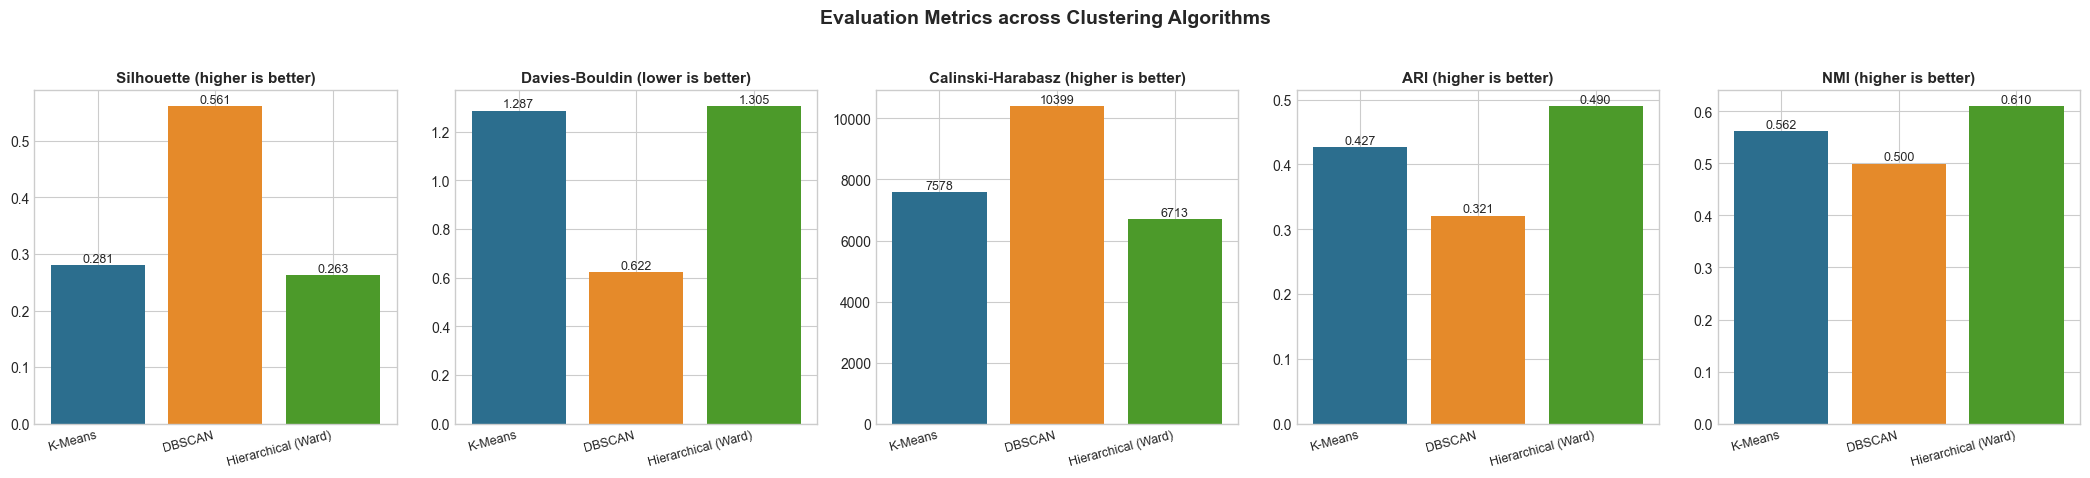

In [22]:
results = pd.DataFrame([
    evaluate(f"K-Means (k={K_BEST})", X_pca, y, labels_kmeans),
    evaluate("K-Means (k=2)", X_pca, y, labels_kmeans2),
    evaluate(f"DBSCAN (eps={EPS_BEST}, min_samples={MS_BEST})", X_pca, y, labels_dbscan),
    evaluate(f"DBSCAN alt (eps={EPS_ALT}, min_samples={MS_ALT})", X_pca, y, labels_dbscan_alt),
    evaluate(f"Hierarchical Ward (k={K_BEST})", X_pca, y, labels_hac),
    evaluate(f"Hierarchical Complete (k={K_BEST})", X_pca, y, link_labels["complete"]),
])
results.to_csv(os.path.join(IMG_DIR, "final_results.csv"), index=False)
print("Final comparison of clustering algorithms (metrics in the 10-D PCA space):")
display(results.round(4))

main = results.iloc[[0, 2, 4]].reset_index(drop=True)
short_names = ["K-Means", "DBSCAN", "Hierarchical (Ward)"]
metric_cols = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz", "ARI", "NMI"]
better = ["higher", "lower", "higher", "higher", "higher"]
fig, axes = plt.subplots(1, 5, figsize=(21, 4.6))
for ax, col, b in zip(axes, metric_cols, better):
    bars = ax.bar(short_names, main[col], color=["#2C6E8E", "#E58A2A", "#4C9A2A"])
    ax.set_title(f"{col} ({b} is better)", fontsize=11, fontweight="bold")
    ax.set_xticklabels(short_names, rotation=15, ha="right", fontsize=9)
    for bar, v in zip(bars, main[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.3f}" if v < 100 else f"{v:.0f}", ha="center", va="bottom", fontsize=9)
plt.suptitle("Evaluation Metrics across Clustering Algorithms", y=1.03, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "metrics_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

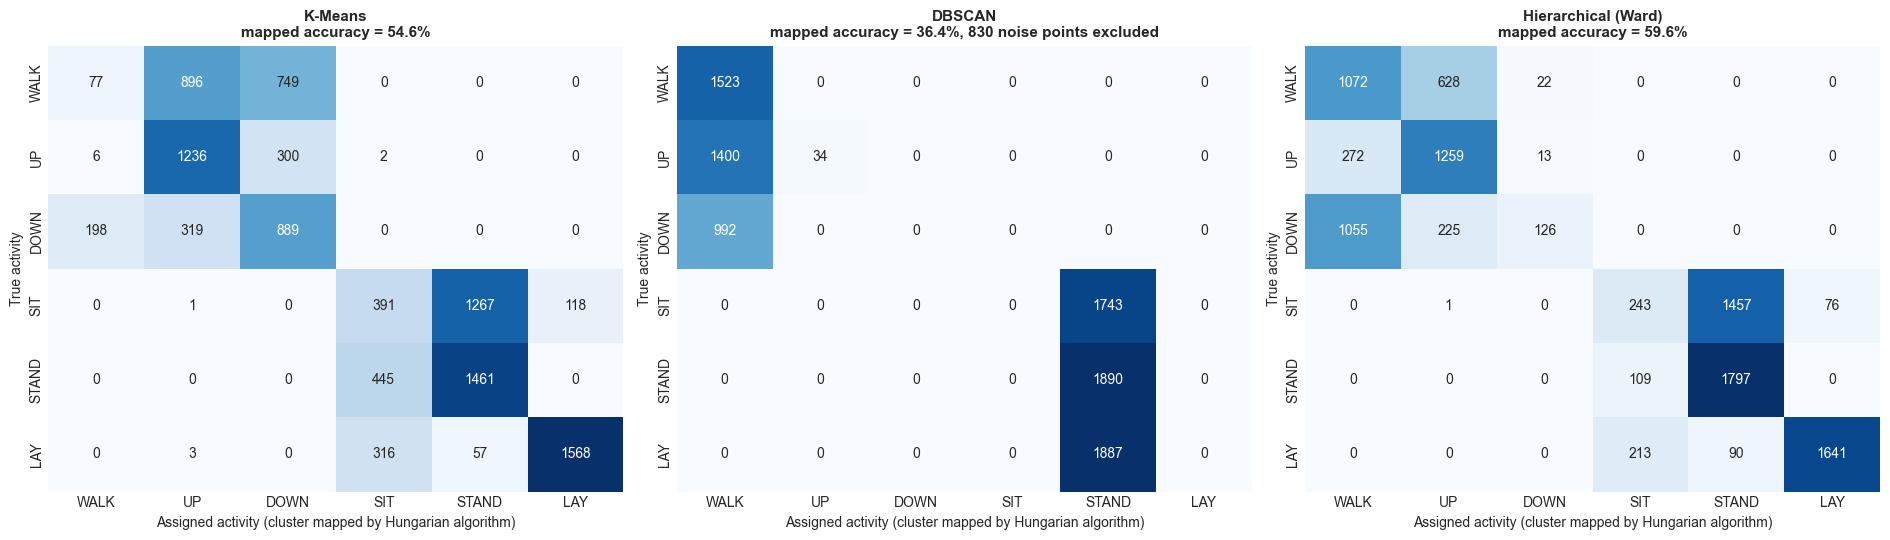

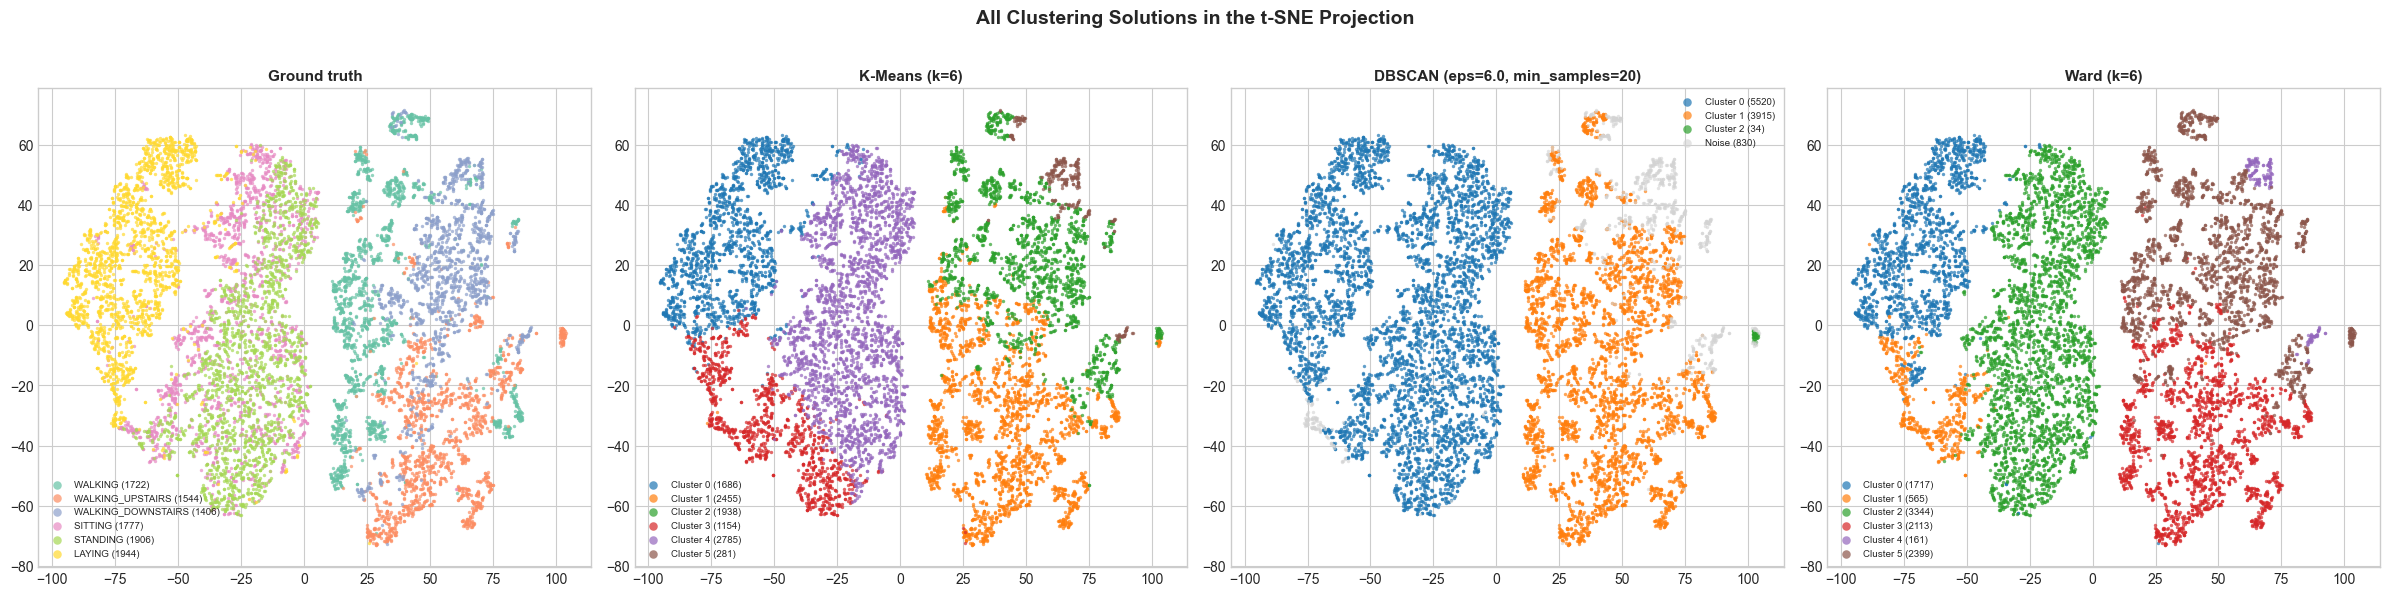

In [23]:
short_labels = ["WALK", "UP", "DOWN", "SIT", "STAND", "LAY"]
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, name, lab in zip(axes, short_names, [labels_kmeans, labels_dbscan, labels_hac]):
    mapped, mapping = map_clusters_to_labels(y, lab)
    valid = mapped != -1
    cm = confusion_matrix(y[valid], mapped[valid], labels=list(range(1, 7)))
    acc = (mapped[valid] == y[valid]).mean()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=short_labels, yticklabels=short_labels, cbar=False)
    extra = f", {(~valid).sum()} noise points excluded" if (~valid).any() else ""
    ax.set_title(f"{name}\nmapped accuracy = {acc*100:.1f}%{extra}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Assigned activity (cluster mapped by Hungarian algorithm)"); ax.set_ylabel("True activity")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "confusion_matrices.png"), dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(24, 5.8))
scatter_by_label(axes[0], X_tsne, y, "Ground truth", label_names=activity_map)
scatter_by_label(axes[1], X_tsne, labels_kmeans, f"K-Means (k={K_BEST})", cmap="tab10")
scatter_by_label(axes[2], X_tsne, labels_dbscan, f"DBSCAN (eps={EPS_BEST}, min_samples={MS_BEST})", cmap="tab10", noise_label=-1)
scatter_by_label(axes[3], X_tsne, labels_hac, f"Ward (k={K_BEST})", cmap="tab10")
plt.suptitle("All Clustering Solutions in the t-SNE Projection", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "cluster_comparison_tsne.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Per-activity view: which activities does each algorithm recover?
Recall of each activity after mapping clusters to activities. This shows where the algorithms agree (static vs dynamic, LAYING) and where they all struggle (SITTING vs STANDING, the three walking variants).

Per-activity recall (%) after Hungarian mapping:


,K-Means,DBSCAN,Hierarchical (Ward)
WALKING,4.5,100.0,62.3
WALKING_UPSTAIRS,80.1,2.4,81.5
WALKING_DOWNSTAIRS,63.2,0.0,9.0
SITTING,22.0,0.0,13.7
STANDING,76.7,100.0,94.3
LAYING,80.7,0.0,84.4


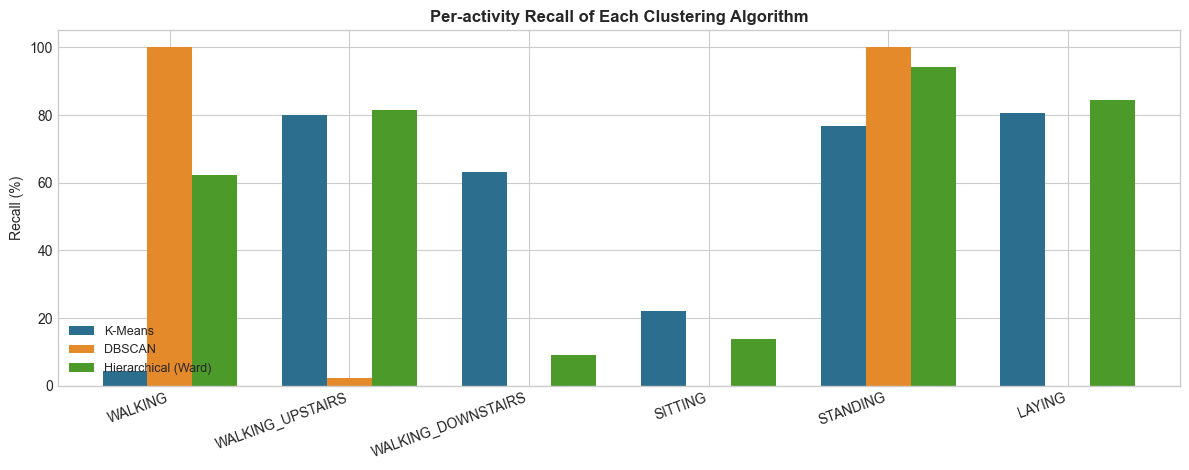

In [24]:
recall_rows = {}
for name, lab in zip(short_names, [labels_kmeans, labels_dbscan, labels_hac]):
    mapped, _ = map_clusters_to_labels(y, lab)
    rec = []
    for c in range(1, 7):
        m = (y == c) & (mapped != -1)
        rec.append((mapped[m] == c).mean() * 100 if m.any() else np.nan)
    recall_rows[name] = rec
recall_df = pd.DataFrame(recall_rows, index=activity_order).round(1)
print("Per-activity recall (%) after Hungarian mapping:")
display(recall_df)

fig, ax = plt.subplots(figsize=(12, 4.8))
recall_df.plot(kind="bar", ax=ax, color=["#2C6E8E", "#E58A2A", "#4C9A2A"], width=0.75)
ax.set_title("Per-activity Recall of Each Clustering Algorithm", fontsize=12, fontweight="bold")
ax.set_ylabel("Recall (%)"); ax.set_ylim(0, 105)
ax.set_xticklabels(activity_order, rotation=20, ha="right")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "per_activity_recall.png"), dpi=300, bbox_inches="tight")
plt.show()

##### Observations and comparative analysis

##### Which algorithm produced the most meaningful clusters? Why?
- Hierarchical clustering with Ward linkage gave the clusters that agree best with the six activities: ARI 0.490, NMI 0.610 and a mapped accuracy of 59.6%, ahead of K-Means with k = 6 (ARI 0.427, NMI 0.562, 54.6%) and DBSCAN (ARI 0.321, NMI 0.500)
- Ward separates LAYING almost perfectly (1,641 of 1,944 windows in one cluster), keeps SITTING and STANDING together in one large cluster and splits the walking windows into an upstairs-dominated cluster and a walking/downstairs cluster. K-Means finds a similar structure but its walking clusters are more mixed
- DBSCAN has the best internal scores (silhouette 0.561, Davies-Bouldin 0.622) but only because it recovers the coarse static versus dynamic split plus one tiny cluster of 34 WALKING_UPSTAIRS windows. Internal metrics reward this two-group structure, exactly as they reward K-Means with k = 2 (silhouette 0.561), so a high silhouette here does not mean the activities were recovered
- No algorithm separates SITTING from STANDING or the three walking variants cleanly. These activities overlap in the feature space (the t-SNE plot shows them as touching regions of one blob), so an unsupervised method that only sees geometry cannot pull them apart

##### How sensitive was K-Means to the choice of k?
- Very sensitive. The silhouette falls from 0.561 at k = 2 to 0.297 at k = 4 and stays between 0.25 and 0.28 for k = 5 to 8, with a small local peak at k = 6 (0.281). ARI moves from 0.33 (k = 2, 3) down to 0.29 (k = 4, 5) and then jumps to 0.43 at k = 6 before dropping again, so the wrong k costs 0.13 ARI
- K-Means was also sensitive to initialisation. With a single random start, 4 of 10 seeds landed in a worse local minimum (WCSS about 888,000 instead of 866,550) whose ARI was only 0.29 versus 0.43 for the good optimum, which is why n_init = 10 was used for every reported model
- Working in the 10-component PCA space did not change the solution: ARI was 0.420 in the full 561-dimensional space, 0.420 with 50 components and 0.427 with 10 components, while the run time fell from 0.71 s to 0.10 s

##### Did DBSCAN detect noise or small clusters effectively?
- Noise detection was sensible: 830 windows (8.1%) were flagged as noise and 723 of them belong to the dynamic activities, mostly WALKING_DOWNSTAIRS (414 windows, 29% of that activity) and WALKING (199). Walking downstairs produces the most variable accelerations, so its windows sit in the sparsest part of the space and are correctly treated as low-density outliers rather than being forced into a cluster
- Small cluster detection was limited. Apart from the two big groups it only found one small cluster of 34 WALKING_UPSTAIRS windows. The alternative setting (eps = 5.5, min_samples = 10) produced more clusters but they were fragments of the same two groups, and lowering eps further just turned points into noise (52% noise at eps = 2.5)
- DBSCAN only worked after PCA. In the 561-dimensional space the 10-nearest-neighbour distances vary by a factor of 11.7 (versus 61.8 in PCA space), and DBSCAN either merged everything into one cluster or marked 38% of the windows as noise

##### How does linkage choice (single/complete/ward) affect hierarchical clustering?
- Single linkage chained everything into one cluster of 10,293 windows plus five singletons (ARI 0.000), average linkage gave two large clusters plus four tiny ones (the static/dynamic split, ARI 0.330) and complete linkage produced one cluster of 9,912 windows with small satellites (ARI 0.004)
- Ward linkage was the only criterion that gave balanced clusters (3,344 / 2,399 / 2,113 / 1,717 / 565 / 161) and it had the best ARI (0.490) and NMI (0.610). Ward merges the pair of clusters that increases the within-cluster variance the least, which favours compact, similar-sized groups, while single and average linkage let a few outliers form their own clusters and merge everything else
- The dendrogram merge heights confirm the coarse structure: the last merge (2 clusters) happens at height 2,236, far above the next one at 754, so the static/dynamic split is by far the strongest structure in the data, with smaller jumps at 3 and 6 clusters

##### Which internal metric best matched visual intuition of cluster quality?
- The Calinski-Harabasz index matched the visual impression best. It strongly penalised the degenerate single (31.9) and complete (379) linkage solutions that look wrong in the t-SNE plots and gave the highest values to the solutions that visually follow the two dense groups (16,613 for k = 2, 10,399 for DBSCAN, 6,713 for Ward)
- Silhouette and Davies-Bouldin were misleading for degenerate solutions: single linkage got a silhouette of 0.370 and the best Davies-Bouldin index of all (0.311) even though it is one giant cluster with singletons, because both metrics only look at separation relative to spread and a singleton is perfectly compact
- All internal metrics prefer the coarse two-cluster view, whereas the external metrics (ARI, NMI) prefer six clusters. This is the main lesson of the experiment: internal metrics measure geometric compactness, and the geometry of this dataset has two strong groups, not six

##### Summary
- Final models: K-Means (k = 6, ARI 0.427, NMI 0.562), DBSCAN (eps = 6.0, min_samples = 20, 3 clusters, 8.1% noise, ARI 0.321, NMI 0.500) and Ward hierarchical clustering (6 clusters, ARI 0.490, NMI 0.610)
- Hierarchical clustering with Ward linkage is the best choice for this dataset, K-Means is close behind and much faster, and DBSCAN is useful for finding outlying windows but not for recovering the six activities